# Projeto Semantix - Previsão de atraso em entregas no e-commerce brasileiro

## Contexto do projeto

Em operações de e-commerce, a entrega é uma das etapas mais importantes da experiência do cliente. Mesmo quando o produto, o preço e o atendimento são satisfatórios, um atraso na entrega pode comprometer a percepção de qualidade do serviço, gerar avaliações negativas e reduzir a confiança do consumidor na empresa.

Neste projeto, será analisado um conjunto de dados público da Olist, marketplace brasileiro que reúne informações sobre pedidos, clientes, vendedores, produtos, pagamentos, frete, prazos de entrega e avaliações realizadas pelos consumidores. A partir desses dados, o objetivo é investigar quais fatores estão associados ao atraso nas entregas e como esse atraso se relaciona com a satisfação do cliente.

A análise será conduzida de forma progressiva, começando pelo entendimento da estrutura dos dados, identificação das principais variáveis, tratamento das informações e construção de uma base analítica consolidada. Em seguida, serão realizadas análises exploratórias para responder perguntas de negócio relacionadas ao comportamento dos pedidos, tempo de entrega, regiões com maior ocorrência de atraso, categorias de produtos mais críticas e impacto dos atrasos nas avaliações.

Além da análise exploratória, o projeto também terá uma etapa de modelagem preditiva. Será construída uma variável-alvo indicando se o pedido foi entregue com atraso ou dentro do prazo estimado, permitindo testar modelos de machine learning capazes de identificar pedidos com maior risco de atraso.

Com isso, o projeto busca demonstrar como o uso de dados pode apoiar a tomada de decisão em problemas reais de negócio, especialmente em contextos logísticos e de experiência do cliente. A proposta está alinhada ao briefing do projeto final, que orienta a escolha de uma problemática real, o uso de dados públicos, a realização de análise exploratória, a construção de um modelo estatístico ou de machine learning e a apresentação dos resultados por meio de visualizações.

---

## Pergunta de negócio

A pergunta principal que orienta este projeto é:

**É possível identificar os principais fatores associados ao atraso nas entregas e construir um modelo capaz de prever pedidos com maior risco de atraso no e-commerce brasileiro?**

A partir dessa pergunta central, o projeto também buscará responder questões complementares:

- Qual é o percentual de pedidos entregues com atraso?
- Como o tempo de entrega se comporta na base analisada?
- Quais estados apresentam maior ocorrência de atraso?
- Quais categorias de produtos possuem maior risco de atraso?
- O valor do frete e o valor do pedido possuem relação com o atraso?
- O atraso na entrega impacta a avaliação feita pelo cliente?
- Quais variáveis são mais relevantes para prever o risco de atraso?

---

## Base de dados utilizada

A base utilizada neste projeto é a **Brazilian E-Commerce Public Dataset by Olist**, disponibilizada publicamente no Kaggle. O conjunto de dados contém informações de pedidos realizados em marketplaces brasileiros, permitindo analisar diferentes aspectos da jornada de compra, desde a realização do pedido até a entrega e avaliação do cliente.

Os dados são compostos por diferentes arquivos em formato CSV, relacionados entre si por identificadores como `order_id`, `customer_id`, `seller_id` e `product_id`.

| Arquivo | Conteúdo | Uso no projeto |
|---|---|---|
| `olist_orders_dataset.csv` | Informações principais dos pedidos, incluindo status, data da compra, aprovação, envio, entrega real e entrega estimada | Base principal para cálculo do prazo de entrega e criação da variável de atraso |
| `olist_order_items_dataset.csv` | Informações dos itens vendidos em cada pedido, como produto, vendedor, preço e valor do frete | Utilizado para analisar preço, frete e relação com vendedores |
| `olist_order_reviews_dataset.csv` | Avaliações realizadas pelos clientes, incluindo nota e comentários | Utilizado para analisar o impacto do atraso na satisfação do cliente |
| `olist_customers_dataset.csv` | Informações dos clientes, como cidade e estado | Utilizado para análise regional dos atrasos |
| `olist_sellers_dataset.csv` | Informações dos vendedores, como cidade e estado | Utilizado para análise da origem dos vendedores |
| `olist_products_dataset.csv` | Informações dos produtos, como categoria, peso e dimensões | Utilizado para análise por categoria e características dos produtos |
| `product_category_name_translation.csv` | Tradução das categorias de produto do português para o inglês | Utilizado para facilitar a leitura das categorias |
| `olist_order_payments_dataset.csv` | Informações de pagamento, como tipo, parcelas e valor pago | Poderá ser utilizado como variável complementar |
| `olist_geolocation_dataset.csv` | Dados geográficos de cidades e estados | Poderá ser utilizado em análises complementares |

---

## Principais variáveis do projeto

Antes de iniciar a análise, é importante destacar algumas das variáveis que terão papel relevante na construção da base analítica e na modelagem preditiva.

| Variável | Tabela de origem | Descrição | Uso no projeto |
|---|---|---|---|
| `order_id` | `orders`, `order_items`, `reviews`, `payments` | Identificador único do pedido | Chave de integração entre as tabelas |
| `customer_id` | `orders`, `customers` | Identificador do cliente associado ao pedido | Integração com dados de localização do cliente |
| `order_status` | `orders` | Situação do pedido | Filtro para considerar apenas pedidos entregues |
| `order_purchase_timestamp` | `orders` | Data e hora em que o pedido foi realizado | Cálculo do tempo total do pedido |
| `order_delivered_customer_date` | `orders` | Data em que o pedido foi entregue ao cliente | Cálculo da entrega real |
| `order_estimated_delivery_date` | `orders` | Data estimada de entrega informada ao cliente | Comparação com a entrega real |
| `price` | `order_items` | Valor do produto vendido | Variável explicativa para análise e modelo |
| `freight_value` | `order_items` | Valor do frete | Variável explicativa para análise operacional |
| `product_id` | `order_items`, `products` | Identificador do produto | Integração com informações do produto |
| `seller_id` | `order_items`, `sellers` | Identificador do vendedor | Integração com dados do vendedor |
| `product_category_name` | `products` | Categoria do produto | Análise de atraso por categoria |
| `customer_state` | `customers` | Estado do cliente | Análise regional dos atrasos |
| `seller_state` | `sellers` | Estado do vendedor | Análise da origem dos vendedores |
| `review_score` | `reviews` | Nota atribuída pelo cliente ao pedido | Análise de satisfação |
| `atraso` | Variável criada | Indica se o pedido foi entregue após a data estimada | Variável-alvo do modelo preditivo |

---

## Estratégia de análise

O desenvolvimento do projeto será realizado em etapas. Primeiro, será feito o carregamento das bases e a compreensão inicial da estrutura dos dados. Em seguida, as tabelas relevantes serão integradas para formar uma base analítica única.

Após a construção da base analítica, serão criadas variáveis auxiliares, como tempo de entrega, diferença entre entrega real e entrega estimada e indicador de atraso. Essas variáveis permitirão avaliar o comportamento dos pedidos e identificar padrões associados ao atraso.

Na etapa de análise exploratória, serão utilizadas tabelas, estatísticas descritivas e visualizações gráficas para investigar os principais fatores relacionados ao atraso nas entregas. Por fim, será construída uma etapa de modelagem preditiva, com o objetivo de testar modelos de machine learning capazes de identificar pedidos com maior risco de atraso.

---

## Resultado esperado

Ao final do projeto, espera-se obter:

- Uma base analítica consolidada a partir dos arquivos da Olist;
- Uma análise exploratória com os principais padrões de atraso;
- Visualizações que facilitem a interpretação dos resultados;
- Um modelo de machine learning para previsão de atraso;
- Uma avaliação do desempenho do modelo;
- Uma conclusão com os principais insights encontrados e possíveis recomendações de negócio.

## Preparação do ambiente

Nesta etapa, serão importadas as bibliotecas necessárias para o desenvolvimento do projeto. Também serão definidas algumas configurações iniciais para facilitar a visualização dos dados e padronizar a exibição dos resultados ao longo do notebook.

## Carregamento das bases de dados

Nesta etapa, serão carregados os arquivos da base Olist que serão utilizados no projeto. Os dados estão armazenados na pasta `input`, que contém os arquivos CSV baixados do Kaggle.

Como o notebook está salvo dentro da pasta `notebooks`, o caminho utilizado para acessar os dados será `../input/`.

In [101]:
# Importando bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Importando bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Importando bibliotecas para modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve

# Importando métricas de avaliação dos modelos
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Removendo avisos para deixar a visualização do notebook mais limpa
import warnings
warnings.filterwarnings('ignore')

# Configurando exibição de colunas e casas decimais
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Configurando tamanho padrão dos gráficos
plt.rcParams['figure.figsize'] = (10, 6)

print('Bibliotecas importadas e ambiente configurado com sucesso.')

Bibliotecas importadas e ambiente configurado com sucesso.


In [5]:
# Definindo o caminho da pasta onde estão os arquivos CSV

caminho = '../input/'

# Carregando as bases de dados da Olist

orders = pd.read_csv(caminho + 'olist_orders_dataset.csv')
order_items = pd.read_csv(caminho + 'olist_order_items_dataset.csv')
order_reviews = pd.read_csv(caminho + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(caminho + 'olist_customers_dataset.csv')
sellers = pd.read_csv(caminho + 'olist_sellers_dataset.csv')
products = pd.read_csv(caminho + 'olist_products_dataset.csv')
payments = pd.read_csv(caminho + 'olist_order_payments_dataset.csv')
geolocation = pd.read_csv(caminho + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(caminho + 'product_category_name_translation.csv')

print('Bases carregadas com sucesso.')

Bases carregadas com sucesso.


## Conferência inicial das bases carregadas

Após o carregamento dos arquivos, será feita uma verificação inicial das bases disponíveis. O objetivo desta etapa é conferir o tamanho de cada tabela e garantir que os arquivos foram lidos corretamente antes de avançar para a análise e tratamento dos dados.

In [6]:
# Criando uma tabela resumo com a quantidade de linhas e colunas de cada base

resumo_bases = pd.DataFrame({
    'Base': [
        'orders',
        'order_items',
        'order_reviews',
        'customers',
        'sellers',
        'products',
        'payments',
        'geolocation',
        'category_translation'
    ],
    'Linhas': [
        orders.shape[0],
        order_items.shape[0],
        order_reviews.shape[0],
        customers.shape[0],
        sellers.shape[0],
        products.shape[0],
        payments.shape[0],
        geolocation.shape[0],
        category_translation.shape[0]
    ],
    'Colunas': [
        orders.shape[1],
        order_items.shape[1],
        order_reviews.shape[1],
        customers.shape[1],
        sellers.shape[1],
        products.shape[1],
        payments.shape[1],
        geolocation.shape[1],
        category_translation.shape[1]
    ]
})

print('Resumo das bases carregadas:')
resumo_bases

Resumo das bases carregadas:


,Base,Linhas,Colunas
0,orders,99441,8
1,order_items,112650,7
2,order_reviews,99224,7
3,customers,99441,5
4,sellers,3095,4
5,products,32951,9
6,payments,103886,5
7,geolocation,1000163,5
8,category_translation,71,2


## Visualização inicial das bases

Nesta etapa, serão exibidas as primeiras linhas de cada base para compreender a estrutura dos dados, os nomes das colunas e o tipo de informação disponível em cada arquivo. Essa visualização inicial ajuda a identificar quais tabelas serão mais relevantes para a construção da base analítica do projeto.

In [7]:
# Visualizando as primeiras linhas da base principal de pedidos

print('Primeiras linhas da base orders:')
orders.head()

Primeiras linhas da base orders:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Estrutura das colunas disponíveis

Após visualizar a base principal de pedidos, será feita uma conferência das colunas disponíveis em cada tabela. Essa etapa ajuda a identificar as chaves de relacionamento entre as bases e as variáveis que poderão ser utilizadas na análise exploratória e na modelagem preditiva.

In [8]:
# Criando uma tabela com as colunas disponíveis em cada base

colunas_bases = pd.DataFrame({
    'Base': [
        'orders',
        'order_items',
        'order_reviews',
        'customers',
        'sellers',
        'products',
        'payments',
        'geolocation',
        'category_translation'
    ],
    'Colunas disponíveis': [
        ', '.join(orders.columns),
        ', '.join(order_items.columns),
        ', '.join(order_reviews.columns),
        ', '.join(customers.columns),
        ', '.join(sellers.columns),
        ', '.join(products.columns),
        ', '.join(payments.columns),
        ', '.join(geolocation.columns),
        ', '.join(category_translation.columns)
    ]
})

print('Colunas disponíveis em cada base:')
colunas_bases

Colunas disponíveis em cada base:


,Base,Colunas disponíveis
0,orders,"order_id, customer_id, order_status, order_pur..."
1,order_items,"order_id, order_item_id, product_id, seller_id..."
2,order_reviews,"review_id, order_id, review_score, review_comm..."
3,customers,"customer_id, customer_unique_id, customer_zip_..."
4,sellers,"seller_id, seller_zip_code_prefix, seller_city..."
5,products,"product_id, product_category_name, product_nam..."
6,payments,"order_id, payment_sequential, payment_type, pa..."
7,geolocation,"geolocation_zip_code_prefix, geolocation_lat, ..."
8,category_translation,"product_category_name, product_category_name_e..."


A partir da estrutura das colunas, é possível observar que a base `orders` será a tabela central do projeto, pois contém o identificador do pedido, o identificador do cliente, o status do pedido e as datas necessárias para calcular o tempo de entrega e o atraso.

As tabelas `order_items`, `customers`, `sellers`, `products` e `order_reviews` serão utilizadas para enriquecer a análise com informações sobre valor do pedido, frete, localização do cliente, localização do vendedor, categoria do produto e avaliação do cliente.

As tabelas `payments` e `geolocation` poderão ser utilizadas como apoio em análises complementares, mas não serão o foco inicial da construção da base analítica.

## Tipos de dados das bases principais

Nesta etapa, será feita uma verificação dos tipos de dados das principais tabelas utilizadas no projeto. Essa análise é importante porque algumas variáveis, principalmente as datas da base `orders`, precisam estar no formato correto para permitir cálculos de prazo de entrega, diferença entre datas e identificação de atrasos.

In [9]:
# Verificando os tipos de dados das principais bases do projeto

print('Tipos de dados da base orders:')
print(orders.dtypes)

print('\nTipos de dados da base order_items:')
print(order_items.dtypes)

print('\nTipos de dados da base order_reviews:')
print(order_reviews.dtypes)

print('\nTipos de dados da base customers:')
print(customers.dtypes)

print('\nTipos de dados da base sellers:')
print(sellers.dtypes)

print('\nTipos de dados da base products:')
print(products.dtypes)

Tipos de dados da base orders:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Tipos de dados da base order_items:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Tipos de dados da base order_reviews:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

Tipos de dados da base customers:
customer_id                 object
custom

A análise dos tipos de dados mostra que as principais colunas de datas da base `orders` foram carregadas como texto (`object`). Por isso, na etapa de tratamento, será necessário convertê-las para o formato `datetime`, permitindo calcular corretamente o tempo de entrega, a diferença entre a data real e a data estimada e a variável indicadora de atraso.

Também é possível observar que variáveis monetárias, como `price` e `freight_value`, já foram carregadas como numéricas, o que facilita as análises relacionadas ao valor dos produtos e ao frete.

## Resumo dos tipos de dados

Para facilitar a leitura, será criada uma tabela consolidada com os tipos de dados das principais bases utilizadas no projeto.

In [10]:
# Criando uma função simples para organizar os tipos de dados de cada base

def resumo_tipos_dados(df, nome_base):
    return pd.DataFrame({
        'Base': nome_base,
        'Variável': df.columns,
        'Tipo de dado': df.dtypes.values
    })

# Consolidando os tipos de dados das principais bases

tipos_dados = pd.concat([
    resumo_tipos_dados(orders, 'orders'),
    resumo_tipos_dados(order_items, 'order_items'),
    resumo_tipos_dados(order_reviews, 'order_reviews'),
    resumo_tipos_dados(customers, 'customers'),
    resumo_tipos_dados(sellers, 'sellers'),
    resumo_tipos_dados(products, 'products')
], ignore_index=True)

print('Total de variáveis analisadas:', tipos_dados.shape[0])
tipos_dados.head(20)

Total de variáveis analisadas: 40


,Base,Variável,Tipo de dado
0,orders,order_id,object
1,orders,customer_id,object
2,orders,order_status,object
3,orders,order_purchase_timestamp,object
4,orders,order_approved_at,object
5,orders,order_delivered_carrier_date,object
6,orders,order_delivered_customer_date,object
7,orders,order_estimated_delivery_date,object
8,order_items,order_id,object
9,order_items,order_item_id,int64


## Verificação de valores ausentes

Nesta etapa, será analisada a presença de valores ausentes nas principais bases do projeto. Essa verificação é importante para entender a qualidade dos dados e definir quais tratamentos serão necessários antes da construção da base analítica.

Como o objetivo do projeto envolve cálculo de prazo de entrega e identificação de atraso, a atenção principal será dada às colunas de data da base `orders`, além das variáveis relacionadas a produtos, avaliações e localização.

In [11]:
# Criando uma função para resumir valores ausentes por base

def resumo_valores_ausentes(df, nome_base):
    resumo = pd.DataFrame({
        'Base': nome_base,
        'Variável': df.columns,
        'Valores ausentes': df.isna().sum().values,
        'Percentual ausente (%)': (df.isna().mean().values * 100).round(2)
    })
    
    return resumo.sort_values(by='Percentual ausente (%)', ascending=False)

# Consolidando os valores ausentes das principais bases

valores_ausentes = pd.concat([
    resumo_valores_ausentes(orders, 'orders'),
    resumo_valores_ausentes(order_items, 'order_items'),
    resumo_valores_ausentes(order_reviews, 'order_reviews'),
    resumo_valores_ausentes(customers, 'customers'),
    resumo_valores_ausentes(sellers, 'sellers'),
    resumo_valores_ausentes(products, 'products')
], ignore_index=True)

# Filtrando apenas variáveis que possuem valores ausentes

valores_ausentes_filtrado = valores_ausentes[valores_ausentes['Valores ausentes'] > 0]

print('Total de variáveis com valores ausentes:', valores_ausentes_filtrado.shape[0])
valores_ausentes_filtrado.head(20)

Total de variáveis com valores ausentes: 13


,Base,Variável,Valores ausentes,Percentual ausente (%)
0,orders,order_delivered_customer_date,2965,2.98
1,orders,order_delivered_carrier_date,1783,1.79
2,orders,order_approved_at,160,0.16
15,order_reviews,review_comment_title,87656,88.34
16,order_reviews,review_comment_message,58247,58.70
31,products,product_category_name,610,1.85
32,products,product_name_lenght,610,1.85
33,products,product_description_lenght,610,1.85
34,products,product_photos_qty,610,1.85
35,products,product_weight_g,2,0.01


A verificação de valores ausentes mostra que as principais bases possuem dados faltantes em algumas variáveis. Na base `orders`, os valores ausentes estão relacionados principalmente às etapas de aprovação, envio e entrega dos pedidos. Como o projeto tem como foco a análise de atraso em entregas, será necessário manter apenas pedidos com informações suficientes para comparar a data real de entrega com a data estimada.

Na base `order_reviews`, os maiores percentuais de ausência aparecem nos campos de comentários escritos pelos clientes. Esse comportamento é esperado, pois nem todos os consumidores escrevem comentários textuais ao avaliar um pedido. Como a análise utilizará principalmente a variável `review_score`, esses campos não serão prioridade no tratamento.

Na base `products`, há valores ausentes em informações de categoria e características físicas dos produtos. Esses casos serão avaliados durante a construção da base analítica, especialmente porque a categoria do produto será uma variável importante para a análise exploratória.

## Verificação de registros duplicados

Nesta etapa, será verificada a presença de registros duplicados nas principais bases do projeto. A identificação de duplicidades é importante para evitar contagens incorretas, distorções nas análises e problemas na construção da base analítica.

In [12]:
# Verificando registros duplicados nas principais bases

duplicados_bases = pd.DataFrame({
    'Base': [
        'orders',
        'order_items',
        'order_reviews',
        'customers',
        'sellers',
        'products',
        'payments'
    ],
    'Registros duplicados': [
        orders.duplicated().sum(),
        order_items.duplicated().sum(),
        order_reviews.duplicated().sum(),
        customers.duplicated().sum(),
        sellers.duplicated().sum(),
        products.duplicated().sum(),
        payments.duplicated().sum()
    ]
})

print('Resumo de registros duplicados nas bases principais:')
duplicados_bases

Resumo de registros duplicados nas bases principais:


,Base,Registros duplicados
0,orders,0
1,order_items,0
2,order_reviews,0
3,customers,0
4,sellers,0
5,products,0
6,payments,0


A verificação não identificou registros duplicados nas principais bases analisadas. Esse resultado indica que não há necessidade de remover linhas repetidas nesta etapa.

Apesar disso, é importante destacar que algumas tabelas podem possuir mais de uma linha associada ao mesmo pedido. Esse é o caso da base `order_items`, pois um pedido pode conter mais de um item, e da base `payments`, pois um pedido pode ter mais de uma forma ou parcela de pagamento. Por isso, essas bases deverão ser agregadas antes de serem integradas à base principal de pedidos.

## Construção da base analítica

Após a compreensão inicial das bases, será construída uma base analítica consolidada para o projeto. A tabela `orders` será utilizada como base principal, pois contém as informações centrais dos pedidos e as datas necessárias para calcular o atraso.

As demais tabelas serão integradas para adicionar informações relevantes sobre clientes, vendedores, produtos, valores, frete e avaliações.

In [13]:
# Criando uma cópia da base principal de pedidos

df = orders.copy()

print('Dimensão inicial da base analítica:', df.shape)
df.head()

Dimensão inicial da base analítica: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Filtro de pedidos entregues

Como o objetivo do projeto é analisar atrasos em entregas, a base analítica será filtrada para considerar apenas pedidos com status `delivered`. Esse filtro é necessário porque pedidos cancelados, indisponíveis ou ainda em processamento não possuem uma entrega finalizada e poderiam distorcer a análise.

Após o filtro, será possível trabalhar com pedidos que efetivamente chegaram ao cliente e comparar a data real de entrega com a data estimada.

In [14]:
# Verificando a distribuição dos status dos pedidos antes do filtro

status_pedidos = df['order_status'].value_counts().reset_index()
status_pedidos.columns = ['Status do pedido', 'Quantidade']

print('Distribuição dos status dos pedidos:')
status_pedidos

Distribuição dos status dos pedidos:


,Status do pedido,Quantidade
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


A distribuição dos status mostra que a maior parte dos pedidos da base está marcada como `delivered`, ou seja, entregue ao cliente. Como o objetivo do projeto é analisar o atraso em entregas finalizadas, os demais status serão removidos da base analítica.

Esse filtro evita considerar pedidos que ainda estavam em andamento, foram cancelados, estavam indisponíveis ou não chegaram à etapa final de entrega.

In [15]:
# Filtrando apenas pedidos entregues

df = df[df['order_status'] == 'delivered'].copy()

print('Dimensão da base após filtrar pedidos entregues:', df.shape)
df.head()

Dimensão da base após filtrar pedidos entregues: (96478, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Conversão das colunas de data

As colunas de data da base `orders` foram carregadas inicialmente como texto. Para calcular o tempo de entrega, comparar a data real com a data estimada e criar a variável de atraso, essas colunas serão convertidas para o formato `datetime`.

In [16]:
# Convertendo as colunas de data para o formato datetime

colunas_data = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for coluna in colunas_data:
    df[coluna] = pd.to_datetime(df[coluna])

print('Tipos de dados após a conversão das datas:')
df[colunas_data].dtypes

Tipos de dados após a conversão das datas:


order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

## Verificação das datas após o filtro

Após filtrar apenas pedidos entregues e converter as colunas de data, será feita uma nova verificação dos valores ausentes nas datas principais. Essa etapa é necessária porque a criação da variável de atraso depende da existência da data real de entrega e da data estimada.

In [17]:
# Verificando valores ausentes nas colunas de data após o filtro de pedidos entregues

ausentes_datas = pd.DataFrame({
    'Variável': colunas_data,
    'Valores ausentes': df[colunas_data].isna().sum().values,
    'Percentual ausente (%)': (df[colunas_data].isna().mean().values * 100).round(2)
})

print('Valores ausentes nas colunas de data após o filtro de pedidos entregues:')
ausentes_datas

Valores ausentes nas colunas de data após o filtro de pedidos entregues:


,Variável,Valores ausentes,Percentual ausente (%)
0,order_purchase_timestamp,0,0.00
1,order_approved_at,14,0.01
2,order_delivered_carrier_date,2,0.00
3,order_delivered_customer_date,8,0.01
4,order_estimated_delivery_date,0,0.00


A verificação das datas mostra que, mesmo após filtrar apenas pedidos entregues, ainda existem alguns registros sem data real de entrega ao cliente. Como a variável de atraso depende diretamente da comparação entre `order_delivered_customer_date` e `order_estimated_delivery_date`, os pedidos sem data real de entrega serão removidos da base analítica.

Como a quantidade de registros removidos é muito pequena em relação ao total da base, esse tratamento não deve causar impacto relevante na análise.

In [18]:
# Removendo pedidos sem data real de entrega ao cliente

linhas_antes = df.shape[0]

df = df.dropna(subset=['order_delivered_customer_date']).copy()

linhas_depois = df.shape[0]
linhas_removidas = linhas_antes - linhas_depois

print('Linhas antes do tratamento:', linhas_antes)
print('Linhas depois do tratamento:', linhas_depois)
print('Total de linhas removidas:', linhas_removidas)

df.head()

Linhas antes do tratamento: 96478
Linhas depois do tratamento: 96470
Total de linhas removidas: 8


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## Criação das variáveis de prazo e atraso

Com as datas tratadas, serão criadas variáveis auxiliares para medir o desempenho das entregas. Essas variáveis serão fundamentais para a análise exploratória e para a etapa de modelagem preditiva.

A variável `tempo_entrega_dias` representa a quantidade de dias entre a compra e a entrega ao cliente. A variável `diferenca_entrega_dias` representa a diferença entre a data real de entrega e a data estimada. Por fim, a variável `atraso` indica se o pedido foi entregue após o prazo estimado.

In [19]:
# Criando variáveis relacionadas ao tempo de entrega

df['tempo_entrega_dias'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

df['diferenca_entrega_dias'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# Criando a variável-alvo de atraso
# 1 = pedido entregue com atraso
# 0 = pedido entregue dentro do prazo

df['atraso'] = np.where(df['diferenca_entrega_dias'] > 0, 1, 0)

print('Variáveis de prazo e atraso criadas com sucesso.')
df[['order_purchase_timestamp', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date', 
    'tempo_entrega_dias', 
    'diferenca_entrega_dias', 
    'atraso']].head()

Variáveis de prazo e atraso criadas com sucesso.


,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega_dias,diferenca_entrega_dias,atraso
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8,-8,0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13,-6,0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9,-18,0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13,-13,0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2,-10,0


## Distribuição da variável de atraso

Após a criação da variável `atraso`, será analisada sua distribuição na base. Essa etapa é importante para entender o equilíbrio entre as classes, ou seja, a proporção de pedidos entregues dentro do prazo e pedidos entregues com atraso.

Essa análise também será relevante para a etapa de modelagem, pois bases muito desbalanceadas podem influenciar o desempenho dos modelos de classificação.

In [20]:
# Verificando a distribuição da variável de atraso

distribuicao_atraso = df['atraso'].value_counts().reset_index()
distribuicao_atraso.columns = ['Atraso', 'Quantidade']

# Criando coluna percentual
distribuicao_atraso['Percentual (%)'] = (
    distribuicao_atraso['Quantidade'] / distribuicao_atraso['Quantidade'].sum() * 100
).round(2)

# Ajustando o rótulo da variável para facilitar a leitura
distribuicao_atraso['Situação'] = distribuicao_atraso['Atraso'].map({
    0: 'Dentro do prazo',
    1: 'Com atraso'
})

distribuicao_atraso = distribuicao_atraso[['Situação', 'Atraso', 'Quantidade', 'Percentual (%)']]

print('Distribuição dos pedidos por situação de atraso:')
distribuicao_atraso

Distribuição dos pedidos por situação de atraso:


,Situação,Atraso,Quantidade,Percentual (%)
0,Dentro do prazo,0,89936,93.23
1,Com atraso,1,6534,6.77


A distribuição da variável `atraso` mostra que a maioria dos pedidos foi entregue dentro do prazo estimado. Do total analisado, 93,23% dos pedidos foram entregues dentro do prazo, enquanto 6,77% apresentaram atraso.

Esse resultado indica que a base possui desbalanceamento entre as classes, pois os pedidos com atraso representam uma parcela menor dos registros. Essa característica deverá ser considerada na etapa de modelagem, já que modelos de classificação podem apresentar bom desempenho geral ao prever a classe majoritária, mas ter dificuldade em identificar corretamente os casos de atraso.

Mesmo assim, a variável `atraso` é adequada para o projeto, pois representa diretamente o problema de negócio que se deseja investigar: identificar pedidos com maior risco de entrega fora do prazo.

## Agregação da base de itens do pedido

A base `order_items` possui uma linha para cada item vendido. Como um mesmo pedido pode conter mais de um produto, essa tabela precisa ser agregada por `order_id` antes de ser integrada à base analítica principal.

Nesta etapa, serão criadas variáveis relacionadas ao valor total dos produtos, valor total do frete, quantidade de itens e quantidade de vendedores associados a cada pedido.

In [21]:
# Agregando informações da base order_items por pedido

order_items_agg = order_items.groupby('order_id').agg(
    quantidade_itens=('order_item_id', 'count'),
    valor_produtos=('price', 'sum'),
    valor_frete=('freight_value', 'sum'),
    quantidade_vendedores=('seller_id', 'nunique')
).reset_index()

print('Dimensão da base order_items agregada:', order_items_agg.shape)
order_items_agg.head()

Dimensão da base order_items agregada: (98666, 5)


,order_id,quantidade_itens,valor_produtos,valor_frete,quantidade_vendedores
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1


## Integração dos itens à base analítica

Após agregar a base `order_items` por pedido, as informações de quantidade de itens, valor dos produtos, valor do frete e quantidade de vendedores serão integradas à base analítica principal.

Essa integração será feita por meio da chave `order_id`, que identifica cada pedido.

In [22]:
# Integrando as informações agregadas de itens à base analítica

linhas_antes = df.shape[0]

df = df.merge(order_items_agg, on='order_id', how='left')

linhas_depois = df.shape[0]

print('Linhas antes da integração:', linhas_antes)
print('Linhas depois da integração:', linhas_depois)
print('Total de colunas após a integração:', df.shape[1])

df.head()

Linhas antes da integração: 96470
Linhas depois da integração: 96470
Total de colunas após a integração: 15


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega_dias,diferenca_entrega_dias,atraso,quantidade_itens,valor_produtos,valor_frete,quantidade_vendedores
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,0,1,29.99,8.72,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,0,1,118.70,22.76,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,0,1,159.90,19.22,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,0,1,45.00,27.20,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,0,1,19.90,8.72,1


## Integração dos dados dos clientes

A base `customers` contém informações de localização dos clientes, como cidade e estado. Esses dados serão integrados à base analítica para permitir análises regionais dos atrasos nas entregas.

A integração será feita pela chave `customer_id`.

In [23]:
# Integrando informações dos clientes à base analítica

linhas_antes = df.shape[0]

df = df.merge(
    customers[['customer_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)

linhas_depois = df.shape[0]

print('Linhas antes da integração:', linhas_antes)
print('Linhas depois da integração:', linhas_depois)
print('Total de colunas após a integração:', df.shape[1])

df[['order_id', 'customer_id', 'customer_city', 'customer_state']].head()

Linhas antes da integração: 96470
Linhas depois da integração: 96470
Total de colunas após a integração: 17


,order_id,customer_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP


## Integração das avaliações dos clientes

A base `order_reviews` contém as avaliações realizadas pelos clientes, incluindo a nota atribuída ao pedido. Como o objetivo do projeto também envolve entender a relação entre atraso e satisfação do cliente, a variável `review_score` será integrada à base analítica.

Antes da integração, a base será agregada por `order_id`, garantindo uma única linha por pedido.

In [24]:
# Agregando as avaliações por pedido

reviews_agg = order_reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean'),
    quantidade_reviews=('review_id', 'count')
).reset_index()

print('Dimensão da base de avaliações agregada:', reviews_agg.shape)
reviews_agg.head()

Dimensão da base de avaliações agregada: (98673, 3)


,order_id,review_score,quantidade_reviews
0,00010242fe8c5a6d1ba2dd792cb16214,5.00,1
1,00018f77f2f0320c557190d7a144bdd3,4.00,1
2,000229ec398224ef6ca0657da4fc703e,5.00,1
3,00024acbcdf0a6daa1e931b038114c75,4.00,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.00,1


## Integração das avaliações à base analítica

Após agregar as avaliações por pedido, a base `reviews_agg` será integrada à base analítica principal. Essa integração permitirá analisar se pedidos entregues com atraso apresentam avaliações mais baixas em comparação aos pedidos entregues dentro do prazo.

In [25]:
# Integrando as avaliações agregadas à base analítica

linhas_antes = df.shape[0]

df = df.merge(reviews_agg, on='order_id', how='left')

linhas_depois = df.shape[0]

print('Linhas antes da integração:', linhas_antes)
print('Linhas depois da integração:', linhas_depois)
print('Total de colunas após a integração:', df.shape[1])

df[['order_id', 'atraso', 'review_score', 'quantidade_reviews']].head()

Linhas antes da integração: 96470
Linhas depois da integração: 96470
Total de colunas após a integração: 19


,order_id,atraso,review_score,quantidade_reviews
0,e481f51cbdc54678b7cc49136f2d6af7,0,4.00,1.00
1,53cdb2fc8bc7dce0b6741e2150273451,0,4.00,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,0,5.00,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,0,5.00,1.00
4,ad21c59c0840e6cb83a9ceb5573f8159,0,5.00,1.00


## Preparação da base de produtos

A base `products` contém informações sobre os produtos vendidos, incluindo a categoria original em português e algumas características físicas. Para facilitar a interpretação das categorias durante a análise exploratória, será integrada também a tabela `category_translation`, que contém a tradução das categorias para o inglês.

Como a base de produtos está no nível do produto (`product_id`) e a base analítica está no nível do pedido (`order_id`), primeiro será criada uma base auxiliar conectando pedido e produto a partir da tabela `order_items`.

In [26]:
# Integrando a tradução das categorias à base de produtos

products_traduzidos = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

print('Dimensão da base de produtos com categorias traduzidas:', products_traduzidos.shape)
products_traduzidos[['product_id', 'product_category_name', 'product_category_name_english']].head()

Dimensão da base de produtos com categorias traduzidas: (32951, 10)


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


## Integração das categorias de produtos aos pedidos

Como a base analítica está no nível do pedido, será criada uma base auxiliar relacionando cada `order_id` às informações de categoria dos produtos. Para isso, a tabela `order_items` será conectada à base de produtos traduzida por meio da chave `product_id`.

Em pedidos com mais de um produto, será considerada a primeira categoria associada ao pedido, permitindo uma representação simplificada da categoria principal do pedido.

In [27]:
# Criando uma base auxiliar com pedido e categoria do produto

pedido_produto = order_items[['order_id', 'product_id']].merge(
    products_traduzidos[['product_id', 'product_category_name', 'product_category_name_english']],
    on='product_id',
    how='left'
)

# Agregando para manter uma linha por pedido

pedido_produto_agg = pedido_produto.groupby('order_id').agg(
    product_category_name=('product_category_name', 'first'),
    product_category_name_english=('product_category_name_english', 'first')
).reset_index()

print('Dimensão da base de categorias por pedido:', pedido_produto_agg.shape)
pedido_produto_agg.head()

Dimensão da base de categorias por pedido: (98666, 3)


,order_id,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,ferramentas_jardim,garden_tools


## Integração das categorias à base analítica

Após criar a base auxiliar com a categoria principal de cada pedido, essas informações serão integradas à base analítica principal. Essa etapa permitirá analisar a relação entre categorias de produtos e atraso nas entregas.

In [28]:
# Integrando as categorias de produtos à base analítica

linhas_antes = df.shape[0]

df = df.merge(pedido_produto_agg, on='order_id', how='left')

linhas_depois = df.shape[0]

print('Linhas antes da integração:', linhas_antes)
print('Linhas depois da integração:', linhas_depois)
print('Total de colunas após a integração:', df.shape[1])

df[['order_id', 'product_category_name', 'product_category_name_english']].head()

Linhas antes da integração: 96470
Linhas depois da integração: 96470
Total de colunas após a integração: 21


,order_id,product_category_name,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,papelaria,stationery


## Integração dos dados dos vendedores

A base `sellers` contém informações de localização dos vendedores, como cidade e estado. Esses dados serão integrados à base analítica para permitir análises relacionadas à origem dos vendedores e sua possível relação com atrasos nas entregas.

Como a base analítica está no nível do pedido, será criada uma base auxiliar com um vendedor principal por `order_id`, a partir da tabela `order_items`.

In [29]:
# Criando uma base auxiliar com vendedor por pedido

pedido_vendedor = order_items[['order_id', 'seller_id']].drop_duplicates()

# Em pedidos com mais de um vendedor, será considerado o primeiro vendedor associado ao pedido
pedido_vendedor_agg = pedido_vendedor.groupby('order_id').agg(
    seller_id=('seller_id', 'first')
).reset_index()

# Integrando informações de localização dos vendedores

pedido_vendedor_agg = pedido_vendedor_agg.merge(
    sellers[['seller_id', 'seller_city', 'seller_state']],
    on='seller_id',
    how='left'
)

print('Dimensão da base de vendedores por pedido:', pedido_vendedor_agg.shape)
pedido_vendedor_agg.head()

Dimensão da base de vendedores por pedido: (98666, 4)


,order_id,seller_id,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,loanda,PR


## Integração dos vendedores à base analítica

Após criar a base auxiliar com o vendedor principal de cada pedido, as informações de cidade e estado do vendedor serão integradas à base analítica principal. Essa etapa permitirá comparar a localização do cliente e do vendedor em análises posteriores.

In [30]:
# Integrando os dados dos vendedores à base analítica

linhas_antes = df.shape[0]

df = df.merge(pedido_vendedor_agg, on='order_id', how='left')

linhas_depois = df.shape[0]

print('Linhas antes da integração:', linhas_antes)
print('Linhas depois da integração:', linhas_depois)
print('Total de colunas após a integração:', df.shape[1])

df[['order_id', 'seller_id', 'seller_city', 'seller_state']].head()

Linhas antes da integração: 96470
Linhas depois da integração: 96470
Total de colunas após a integração: 24


,order_id,seller_id,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,66922902710d126a0e7d26b0e3805106,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,SP


## Conferência da base analítica consolidada

Após a integração das bases de pedidos, itens, clientes, avaliações, produtos e vendedores, será feita uma conferência geral da base analítica consolidada. O objetivo é verificar a dimensão final da base, as colunas disponíveis e possíveis valores ausentes após as integrações.

Essa etapa é importante para garantir que a base está adequada para a análise exploratória e para a modelagem preditiva.

In [31]:
# Conferindo a dimensão final da base analítica consolidada

print('Dimensão final da base analítica:', df.shape)
df.head()

Dimensão final da base analítica: (96470, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega_dias,diferenca_entrega_dias,atraso,quantidade_itens,valor_produtos,valor_frete,quantidade_vendedores,customer_city,customer_state,review_score,quantidade_reviews,product_category_name,product_category_name_english,seller_id,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,0,1,29.99,8.72,1,sao paulo,SP,4.00,1.00,utilidades_domesticas,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,0,1,118.70,22.76,1,barreiras,BA,4.00,1.00,perfumaria,perfumery,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,0,1,159.90,19.22,1,vianopolis,GO,5.00,1.00,automotivo,auto,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,0,1,45.00,27.20,1,sao goncalo do amarante,RN,5.00,1.00,pet_shop,pet_shop,66922902710d126a0e7d26b0e3805106,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,0,1,19.90,8.72,1,santo andre,SP,5.00,1.00,papelaria,stationery,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,SP


In [32]:
# Verificando valores ausentes na base analítica consolidada

ausentes_df = pd.DataFrame({
    'Variável': df.columns,
    'Valores ausentes': df.isna().sum().values,
    'Percentual ausente (%)': (df.isna().mean().values * 100).round(2)
})

ausentes_df = ausentes_df[ausentes_df['Valores ausentes'] > 0].sort_values(
    by='Percentual ausente (%)',
    ascending=False
)

print('Total de variáveis com valores ausentes na base analítica:', ausentes_df.shape[0])
ausentes_df.head(20)

Total de variáveis com valores ausentes na base analítica: 6


,Variável,Valores ausentes,Percentual ausente (%)
20,product_category_name_english,1351,1.40
19,product_category_name,1332,1.38
17,review_score,646,0.67
18,quantidade_reviews,646,0.67
4,order_approved_at,14,0.01
5,order_delivered_carrier_date,1,0.00


A conferência da base analítica consolidada mostra que a base final possui 96.470 pedidos e 24 colunas. Após as integrações, ainda existem alguns valores ausentes, principalmente nas variáveis de categoria do produto e avaliação do cliente.

As categorias ausentes serão preenchidas como `sem_categoria`, pois esses pedidos ainda possuem informações válidas para a análise de prazo e atraso. Já os valores ausentes em `review_score` serão mantidos, pois nem todos os pedidos possuem avaliação registrada. Nas análises relacionadas à satisfação do cliente, serão considerados apenas os pedidos com nota disponível.

As colunas `order_approved_at` e `order_delivered_carrier_date` possuem poucos valores ausentes e não serão utilizadas diretamente na criação da variável de atraso, portanto não exigem remoção de registros neste momento.

In [33]:
# Tratando valores ausentes nas categorias de produto

df['product_category_name'] = df['product_category_name'].fillna('sem_categoria')
df['product_category_name_english'] = df['product_category_name_english'].fillna('sem_categoria')

# Para quantidade de reviews, pedidos sem avaliação registrada recebem 0
df['quantidade_reviews'] = df['quantidade_reviews'].fillna(0)

print('Tratamento de categorias e quantidade de reviews concluído.')

df[['product_category_name', 
    'product_category_name_english', 
    'review_score', 
    'quantidade_reviews']].head()

Tratamento de categorias e quantidade de reviews concluído.


,product_category_name,product_category_name_english,review_score,quantidade_reviews
0,utilidades_domesticas,housewares,4.00,1.00
1,perfumaria,perfumery,4.00,1.00
2,automotivo,auto,5.00,1.00
3,pet_shop,pet_shop,5.00,1.00
4,papelaria,stationery,5.00,1.00


## Nova conferência de valores ausentes

Após o tratamento das categorias de produto e da quantidade de avaliações, será feita uma nova verificação de valores ausentes na base analítica. Essa etapa permite confirmar quais variáveis ainda possuem dados faltantes e decidir se será necessário algum tratamento adicional antes da análise exploratória.

In [34]:
# Verificando novamente os valores ausentes na base analítica

ausentes_df = pd.DataFrame({
    'Variável': df.columns,
    'Valores ausentes': df.isna().sum().values,
    'Percentual ausente (%)': (df.isna().mean().values * 100).round(2)
})

ausentes_df = ausentes_df[ausentes_df['Valores ausentes'] > 0].sort_values(
    by='Percentual ausente (%)',
    ascending=False
)

print('Total de variáveis com valores ausentes após o tratamento:', ausentes_df.shape[0])
ausentes_df.head(20)

Total de variáveis com valores ausentes após o tratamento: 3


,Variável,Valores ausentes,Percentual ausente (%)
17,review_score,646,0.67
4,order_approved_at,14,0.01
5,order_delivered_carrier_date,1,0.00


Após o tratamento das categorias de produto e da quantidade de avaliações, restaram poucos valores ausentes na base analítica. A variável `review_score` será mantida com valores ausentes, pois nem todos os pedidos possuem avaliação registrada. Nas análises relacionadas à satisfação do cliente, serão considerados apenas os pedidos com nota disponível.

As colunas `order_approved_at` e `order_delivered_carrier_date` possuem poucos valores ausentes e não são essenciais para a análise principal de atraso, portanto não será necessário remover novos registros nesta etapa.

Com isso, a base analítica está adequada para o início da análise exploratória.

## Resumo final da base analítica

Antes de iniciar a análise exploratória, será apresentado um resumo da base analítica final, com a quantidade de registros, quantidade de variáveis e principais informações construídas ao longo da preparação dos dados.

In [35]:
# Criando um resumo final da base analítica

resumo_final = pd.DataFrame({
    'Informação': [
        'Total de pedidos analisados',
        'Total de variáveis na base',
        'Pedidos dentro do prazo',
        'Pedidos com atraso',
        'Percentual de pedidos com atraso (%)',
        'Total de estados de clientes',
        'Total de estados de vendedores',
        'Total de categorias de produto'
    ],
    'Valor': [
        df.shape[0],
        df.shape[1],
        df[df['atraso'] == 0].shape[0],
        df[df['atraso'] == 1].shape[0],
        round(df['atraso'].mean() * 100, 2),
        df['customer_state'].nunique(),
        df['seller_state'].nunique(),
        df['product_category_name_english'].nunique()
    ]
})

print('Resumo final da base analítica:')
resumo_final

Resumo final da base analítica:


,Informação,Valor
0,Total de pedidos analisados,96470.00
1,Total de variáveis na base,24.00
2,Pedidos dentro do prazo,89936.00
3,Pedidos com atraso,6534.00
4,Percentual de pedidos com atraso (%),6.77
5,Total de estados de clientes,27.00
6,Total de estados de vendedores,22.00
7,Total de categorias de produto,72.00


# Análise Exploratória de Dados

Nesta etapa, será realizada a análise exploratória da base analítica consolidada. O objetivo é investigar o comportamento dos pedidos, identificar padrões associados ao atraso nas entregas e responder às principais perguntas de negócio definidas no início do projeto.

A análise será conduzida a partir de tabelas, estatísticas descritivas e visualizações gráficas, considerando aspectos como percentual de atraso, tempo de entrega, localização dos clientes, categorias de produtos, valor do frete, valor dos pedidos e avaliação dos clientes.

## Percentual de pedidos com atraso

A primeira análise exploratória consiste em verificar a proporção de pedidos entregues dentro do prazo e pedidos entregues com atraso. Essa informação apresenta uma visão geral do problema e serve como ponto de partida para as próximas análises.

In [36]:
# Calculando a distribuição dos pedidos por situação de atraso

atraso_resumo = df['atraso'].value_counts().reset_index()
atraso_resumo.columns = ['Atraso', 'Quantidade']

atraso_resumo['Percentual (%)'] = (
    atraso_resumo['Quantidade'] / atraso_resumo['Quantidade'].sum() * 100
).round(2)

atraso_resumo['Situação'] = atraso_resumo['Atraso'].map({
    0: 'Dentro do prazo',
    1: 'Com atraso'
})

atraso_resumo = atraso_resumo[['Situação', 'Atraso', 'Quantidade', 'Percentual (%)']]

print('Distribuição dos pedidos por situação de atraso:')
atraso_resumo

Distribuição dos pedidos por situação de atraso:


,Situação,Atraso,Quantidade,Percentual (%)
0,Dentro do prazo,0,89936,93.23
1,Com atraso,1,6534,6.77


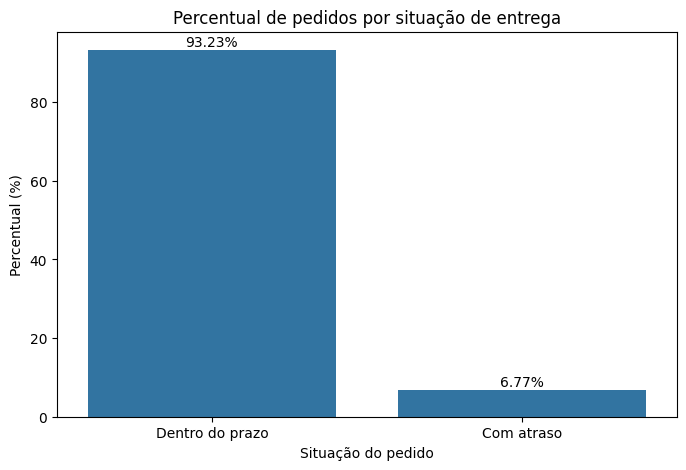

In [37]:
# Visualizando a distribuição dos pedidos por situação de atraso

plt.figure(figsize=(8, 5))

sns.barplot(
    data=atraso_resumo,
    x='Situação',
    y='Percentual (%)'
)

plt.title('Percentual de pedidos por situação de entrega')
plt.xlabel('Situação do pedido')
plt.ylabel('Percentual (%)')

for i, valor in enumerate(atraso_resumo['Percentual (%)']):
    plt.text(i, valor + 1, f'{valor:.2f}%', ha='center')

plt.show()

A análise inicial mostra que a maior parte dos pedidos foi entregue dentro do prazo estimado. Do total de 96.470 pedidos analisados, 89.936 foram entregues dentro do prazo, representando 93,23% da base. Já os pedidos com atraso somam 6.534 registros, correspondendo a 6,77% do total.

Esse resultado indica que o atraso não é o comportamento predominante na base, mas representa um problema relevante para investigação, principalmente por estar relacionado à experiência do cliente e à qualidade percebida do serviço logístico.

Também é importante observar que a variável `atraso` apresenta desbalanceamento entre as classes. Esse ponto deverá ser considerado posteriormente na etapa de modelagem preditiva, pois modelos de classificação podem apresentar boa acurácia geral ao favorecer a classe majoritária, mas ter menor capacidade de identificar corretamente os pedidos com atraso.

## Análise do tempo de entrega

Nesta etapa, será analisado o comportamento do tempo de entrega dos pedidos. A variável `tempo_entrega_dias` representa a quantidade de dias entre a realização da compra e a entrega ao cliente.

Essa análise permite entender o prazo médio de entrega, a dispersão dos prazos e a presença de pedidos com tempos de entrega muito elevados.

In [38]:
# Estatísticas descritivas do tempo de entrega

tempo_entrega_desc = df['tempo_entrega_dias'].describe().reset_index()
tempo_entrega_desc.columns = ['Estatística', 'Valor']

print('Estatísticas descritivas do tempo de entrega:')
tempo_entrega_desc

Estatísticas descritivas do tempo de entrega:


,Estatística,Valor
0,count,96470.00
1,mean,12.09
2,std,9.55
3,min,0.00
4,25%,6.00
5,50%,10.00
6,75%,15.00
7,max,209.00


As estatísticas descritivas mostram que o tempo médio de entrega dos pedidos foi de aproximadamente 12 dias, enquanto a mediana foi de 10 dias. Isso indica que metade dos pedidos foi entregue em até 10 dias após a compra.

Também é possível observar que 75% dos pedidos foram entregues em até 15 dias. No entanto, o valor máximo de 209 dias indica a presença de pedidos com tempos de entrega muito elevados, que podem ser considerados casos extremos e devem ser observados com atenção durante a análise.

Como a média é maior que a mediana, há indícios de assimetria à direita na distribuição do tempo de entrega, possivelmente causada por pedidos com prazos muito longos.

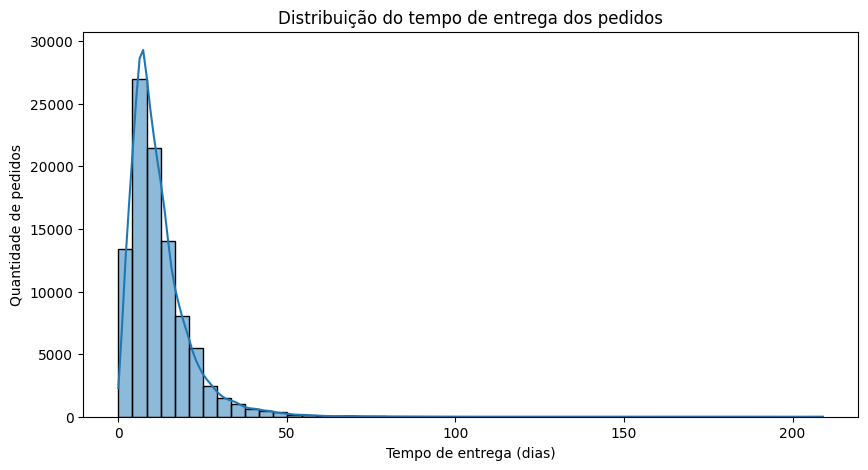

In [39]:
# Visualizando a distribuição do tempo de entrega

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='tempo_entrega_dias',
    bins=50,
    kde=True
)

plt.title('Distribuição do tempo de entrega dos pedidos')
plt.xlabel('Tempo de entrega (dias)')
plt.ylabel('Quantidade de pedidos')

plt.show()

O gráfico de distribuição do tempo de entrega mostra que a maior parte dos pedidos foi entregue em um intervalo relativamente curto, concentrando-se principalmente entre os primeiros dias após a compra e cerca de 20 dias.

A distribuição apresenta assimetria à direita, pois existem alguns pedidos com tempos de entrega muito superiores ao padrão geral da base. Esses casos extremos aumentam a média do tempo de entrega e ajudam a explicar por que a média ficou maior que a mediana.

Esse comportamento indica que, embora a maioria das entregas ocorra em prazos considerados normais, há uma parcela menor de pedidos com prazos muito longos que merece atenção, pois pode estar associada a problemas logísticos, distância entre vendedor e cliente, categoria do produto ou características específicas do pedido.

Percentil 95 do tempo de entrega: 29.0


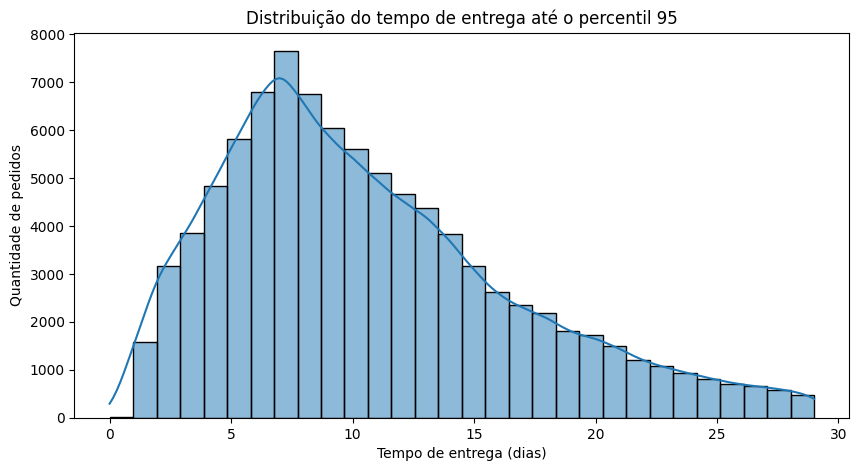

In [40]:
# Visualizando a distribuição do tempo de entrega até o percentil 95

limite_tempo_entrega = df['tempo_entrega_dias'].quantile(0.95)

df_tempo_95 = df[df['tempo_entrega_dias'] <= limite_tempo_entrega]

print('Percentil 95 do tempo de entrega:', limite_tempo_entrega)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_tempo_95,
    x='tempo_entrega_dias',
    bins=30,
    kde=True
)

plt.title('Distribuição do tempo de entrega até o percentil 95')
plt.xlabel('Tempo de entrega (dias)')
plt.ylabel('Quantidade de pedidos')

plt.show()

Ao limitar a visualização até o percentil 95, observa-se com mais clareza o comportamento da maior parte dos pedidos. O resultado mostra que 95% das entregas ocorreram em até 29 dias, indicando que prazos superiores a esse valor representam uma parcela menor da base.

A distribuição continua concentrada nos prazos mais baixos, principalmente entre aproximadamente 5 e 15 dias, com redução gradual da quantidade de pedidos conforme o tempo de entrega aumenta. Esse padrão confirma que a maior parte das entregas ocorre em um intervalo relativamente controlado, enquanto os prazos muito elevados observados anteriormente fazem parte da cauda da distribuição.

Essa análise reforça a importância de investigar os pedidos com atraso separadamente, pois o comportamento geral da base é dominado por pedidos entregues dentro do prazo, enquanto os atrasos podem estar associados a fatores específicos, como região, distância logística, categoria do produto, valor do frete ou características do vendedor.

## Tempo de entrega por situação de atraso

Após analisar a distribuição geral do tempo de entrega, será feita uma comparação entre pedidos entregues dentro do prazo e pedidos entregues com atraso.

Essa análise permite verificar se os pedidos atrasados apresentam tempos de entrega mais elevados e ajuda a entender a diferença de comportamento entre os dois grupos.

In [41]:
# Comparando o tempo de entrega por situação de atraso

tempo_por_atraso = df.groupby('atraso')['tempo_entrega_dias'].describe().reset_index()

tempo_por_atraso['Situação'] = tempo_por_atraso['atraso'].map({
    0: 'Dentro do prazo',
    1: 'Com atraso'
})

tempo_por_atraso = tempo_por_atraso[
    ['Situação', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
]

print('Tempo de entrega por situação de atraso:')
tempo_por_atraso

Tempo de entrega por situação de atraso:


,Situação,count,mean,std,min,25%,50%,75%,max
0,Dentro do prazo,89936.00,10.54,6.32,0.00,6.00,9.00,14.00,70.00
1,Com atraso,6534.00,33.49,17.48,3.00,24.00,31.00,40.00,209.00


A comparação do tempo de entrega por situação de atraso mostra uma diferença significativa entre os pedidos entregues dentro do prazo e os pedidos entregues com atraso.

Os pedidos entregues dentro do prazo apresentaram tempo médio de entrega de aproximadamente 10,54 dias, com mediana de 9 dias. Além disso, 75% desses pedidos foram entregues em até 14 dias, indicando um comportamento mais concentrado em prazos menores.

Já os pedidos com atraso apresentaram tempo médio de entrega de aproximadamente 33,49 dias, com mediana de 31 dias. Nesse grupo, 75% dos pedidos foram entregues em até 40 dias, mostrando que os atrasos estão associados a tempos de entrega consideravelmente mais altos.

Também é possível observar que o valor máximo entre os pedidos atrasados chegou a 209 dias, reforçando a presença de casos extremos. Essa diferença entre os grupos confirma que a variável `tempo_entrega_dias` está diretamente relacionada ao atraso e será importante tanto para a análise exploratória quanto para a compreensão do problema logístico.

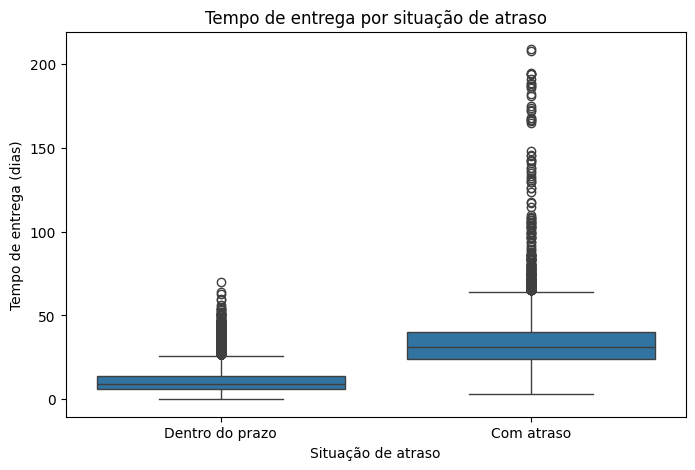

In [42]:
# Visualizando o tempo de entrega por situação de atraso

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='atraso',
    y='tempo_entrega_dias'
)

plt.title('Tempo de entrega por situação de atraso')
plt.xlabel('Situação de atraso')
plt.ylabel('Tempo de entrega (dias)')

plt.xticks(
    ticks=[0, 1],
    labels=['Dentro do prazo', 'Com atraso']
)

plt.show()

O boxplot reforça a diferença de comportamento entre os pedidos entregues dentro do prazo e os pedidos com atraso. Os pedidos dentro do prazo apresentam tempos de entrega mais baixos e concentrados, enquanto os pedidos com atraso possuem mediana e dispersão maiores.

Também é possível observar a presença de valores extremos nos dois grupos, especialmente entre os pedidos atrasados, onde há entregas com tempos muito superiores ao padrão da base. Isso confirma que os atrasos não estão apenas associados a uma pequena diferença de dias, mas a um aumento expressivo no tempo total de entrega.

De forma geral, essa análise mostra que os pedidos atrasados formam um grupo com comportamento logístico distinto, o que justifica investigar outros fatores que possam estar relacionados ao atraso, como região do cliente, localização do vendedor, categoria do produto, valor do frete e valor do pedido.

## Diferença entre entrega real e entrega estimada

Nesta etapa, será analisada a variável `diferenca_entrega_dias`, que representa a diferença entre a data real de entrega ao cliente e a data estimada de entrega.

Valores negativos indicam que o pedido foi entregue antes do prazo estimado. Valores iguais a zero indicam entrega exatamente no prazo. Valores positivos indicam atraso.

In [43]:
# Estatísticas descritivas da diferença entre entrega real e estimada

diferenca_entrega_desc = df['diferenca_entrega_dias'].describe().reset_index()
diferenca_entrega_desc.columns = ['Estatística', 'Valor']

print('Estatísticas descritivas da diferença entre entrega real e estimada:')
diferenca_entrega_desc

Estatísticas descritivas da diferença entre entrega real e estimada:


,Estatística,Valor
0,count,96470.00
1,mean,-11.88
2,std,10.18
3,min,-147.00
4,25%,-17.00
5,50%,-12.00
6,75%,-7.00
7,max,188.00


A análise da diferença entre a entrega real e a entrega estimada mostra que, em média, os pedidos foram entregues antes do prazo previsto. A média da variável `diferenca_entrega_dias` foi de aproximadamente -11,88 dias, enquanto a mediana foi de -12 dias.

Isso indica que metade dos pedidos foi entregue pelo menos 12 dias antes da data estimada. Além disso, 75% dos pedidos apresentaram diferença de até -7 dias, reforçando que a maior parte das entregas ocorreu antes do prazo informado ao cliente.

Por outro lado, o valor máximo de 188 dias mostra que existem pedidos com atraso extremo em relação à data estimada. Esses casos fazem parte da cauda da distribuição e podem indicar problemas logísticos pontuais, falhas operacionais ou situações específicas de determinados pedidos.

De forma geral, essa variável é importante porque mede diretamente o desempenho da entrega em relação ao prazo prometido ao cliente, sendo a base para a criação da variável `atraso`.

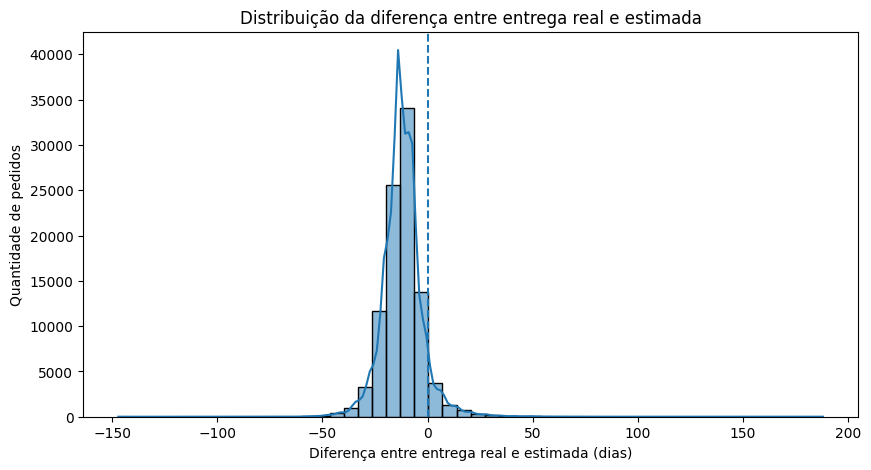

In [44]:
# Visualizando a distribuição da diferença entre entrega real e estimada

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='diferenca_entrega_dias',
    bins=50,
    kde=True
)

plt.axvline(0, linestyle='--')

plt.title('Distribuição da diferença entre entrega real e estimada')
plt.xlabel('Diferença entre entrega real e estimada (dias)')
plt.ylabel('Quantidade de pedidos')

plt.show()

O gráfico da diferença entre a entrega real e a entrega estimada confirma que a maior parte dos pedidos foi entregue antes do prazo informado ao cliente. A concentração principal da distribuição está à esquerda da linha zero, indicando valores negativos para a variável `diferenca_entrega_dias`.

A linha vertical em zero representa o limite entre pedidos entregues dentro do prazo e pedidos com atraso. Valores à esquerda dessa linha indicam entregas antecipadas, enquanto valores à direita indicam pedidos entregues após a data estimada.

Apesar da maior parte da base apresentar entregas antecipadas, o gráfico também evidencia uma cauda à direita, formada por pedidos com atraso. Esses casos são menos frequentes, mas importantes para o objetivo do projeto, pois representam situações em que o prazo prometido ao cliente não foi cumprido.

Essa análise reforça que o atraso é um evento minoritário na base, mas relevante para investigação, especialmente porque pode impactar diretamente a percepção de qualidade do serviço e a satisfação do cliente.

Percentil 1 da diferença de entrega: -36.0
Percentil 99 da diferença de entrega: 18.0


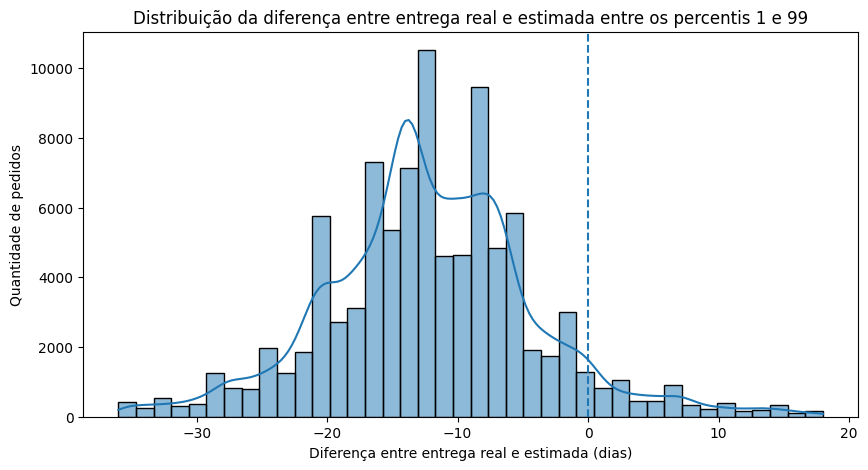

In [45]:
# Visualizando a diferença entre entrega real e estimada entre os percentis 1 e 99

limite_inferior = df['diferenca_entrega_dias'].quantile(0.01)
limite_superior = df['diferenca_entrega_dias'].quantile(0.99)

df_diferenca_filtrada = df[
    (df['diferenca_entrega_dias'] >= limite_inferior) &
    (df['diferenca_entrega_dias'] <= limite_superior)
]

print('Percentil 1 da diferença de entrega:', limite_inferior)
print('Percentil 99 da diferença de entrega:', limite_superior)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_diferenca_filtrada,
    x='diferenca_entrega_dias',
    bins=40,
    kde=True
)

plt.axvline(0, linestyle='--')

plt.title('Distribuição da diferença entre entrega real e estimada entre os percentis 1 e 99')
plt.xlabel('Diferença entre entrega real e estimada (dias)')
plt.ylabel('Quantidade de pedidos')

plt.show()

Ao limitar a visualização entre os percentis 1 e 99, a distribuição da diferença entre entrega real e estimada fica mais clara. A maior parte dos pedidos permanece concentrada em valores negativos, confirmando que muitos pedidos foram entregues antes da data estimada.

O percentil 1 foi de -36 dias, indicando que apenas uma pequena parcela dos pedidos foi entregue mais de 36 dias antes do prazo. Já o percentil 99 foi de 18 dias, mostrando que 99% dos pedidos tiveram diferença de até 18 dias em relação à data estimada.

A linha vertical em zero continua separando os pedidos entregues dentro do prazo dos pedidos com atraso. Mesmo com a remoção visual dos extremos, observa-se que a maior concentração está à esquerda dessa linha, enquanto os pedidos atrasados aparecem em menor proporção à direita.

Essa análise confirma que o atraso é menos frequente, mas ainda relevante para investigação, principalmente porque representa os casos em que a expectativa de prazo informada ao cliente não foi cumprida.

## Atraso por estado do cliente

Nesta etapa, será analisada a distribuição dos pedidos e do percentual de atraso por estado do cliente. Essa análise permite verificar se determinadas regiões apresentam maior concentração de pedidos atrasados.

Como alguns estados podem ter poucos pedidos, será importante observar tanto a quantidade total de pedidos quanto o percentual de atraso, evitando conclusões baseadas apenas em proporções de bases muito pequenas.

In [46]:
# Analisando o percentual de atraso por estado do cliente

atraso_estado_cliente = df.groupby('customer_state').agg(
    total_pedidos=('order_id', 'count'),
    pedidos_atrasados=('atraso', 'sum'),
    percentual_atraso=('atraso', 'mean')
).reset_index()

atraso_estado_cliente['percentual_atraso'] = (
    atraso_estado_cliente['percentual_atraso'] * 100
).round(2)

atraso_estado_cliente = atraso_estado_cliente.sort_values(
    by='percentual_atraso',
    ascending=False
)

print('Percentual de atraso por estado do cliente:')
atraso_estado_cliente.head(10)

Percentual de atraso por estado do cliente:


,customer_state,total_pedidos,pedidos_atrasados,percentual_atraso
1,AL,397,85,21.41
9,MA,717,125,17.43
24,SE,335,51,15.22
16,PI,476,66,13.87
5,CE,1279,176,13.76
21,RR,41,5,12.20
4,BA,3256,396,12.16
18,RJ,12350,1495,12.11
13,PA,946,106,11.21
7,ES,1995,214,10.73


A análise por estado do cliente mostra que alguns estados apresentam percentuais de atraso superiores à média geral da base. Entre os maiores percentuais, destacam-se AL, MA, SE, PI e CE.

O estado de AL apresentou o maior percentual de atraso, com 21,41% dos pedidos entregues fora do prazo. No entanto, é importante observar que esse resultado está baseado em 397 pedidos, uma quantidade menor quando comparada a estados com maior volume de pedidos.

Estados como CE, BA e RJ também apresentam percentuais relevantes de atraso e possuem volumes maiores de pedidos. Por isso, esses estados podem ter maior impacto operacional na análise, pois combinam quantidade expressiva de pedidos com proporção considerável de atrasos.

Essa etapa reforça a importância de analisar percentual e volume em conjunto. Um estado com percentual alto, mas poucos pedidos, pode indicar um comportamento pontual, enquanto estados com muitos pedidos e percentual elevado podem representar um problema logístico mais relevante para o negócio.

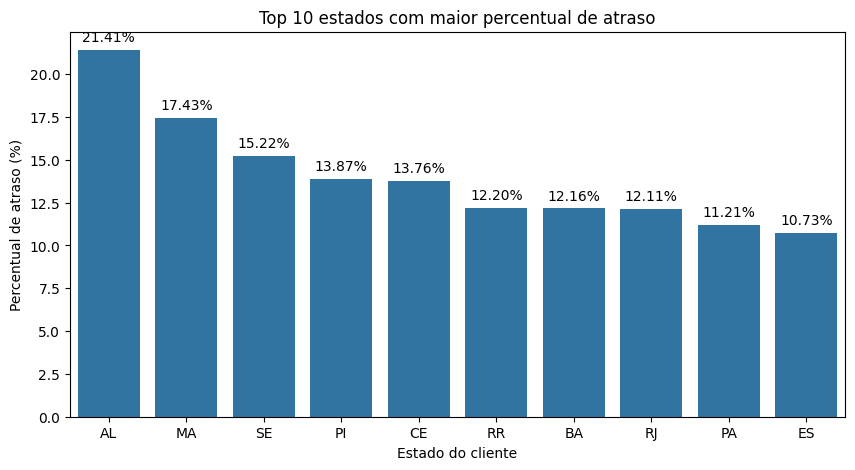

In [47]:
# Visualizando os estados com maior percentual de atraso

top_estados_atraso = atraso_estado_cliente.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_estados_atraso,
    x='customer_state',
    y='percentual_atraso'
)

plt.title('Top 10 estados com maior percentual de atraso')
plt.xlabel('Estado do cliente')
plt.ylabel('Percentual de atraso (%)')

for i, valor in enumerate(top_estados_atraso['percentual_atraso']):
    plt.text(i, valor + 0.5, f'{valor:.2f}%', ha='center')

plt.show()

O gráfico dos 10 estados com maior percentual de atraso mostra que AL apresentou a maior proporção de pedidos atrasados, com 21,41%. Em seguida aparecem MA, SE, PI e CE, todos com percentuais de atraso superiores à média geral observada na base.

Apesar disso, essa análise deve ser interpretada com cautela. O percentual de atraso mostra a proporção de problemas dentro de cada estado, mas não informa sozinho o impacto operacional total. Estados com menor quantidade de pedidos podem apresentar percentuais elevados, mesmo com um número absoluto menor de atrasos.

Por esse motivo, é importante complementar essa visualização com a análise do volume total de pedidos e da quantidade absoluta de pedidos atrasados por estado. Dessa forma, será possível identificar não apenas os estados com maior proporção de atraso, mas também aqueles que mais contribuem para o total de pedidos atrasados na operação.

In [48]:
# Analisando os estados com maior quantidade absoluta de pedidos atrasados

volume_atraso_estado = atraso_estado_cliente.sort_values(
    by='pedidos_atrasados',
    ascending=False
)

print('Estados com maior quantidade de pedidos atrasados:')
volume_atraso_estado.head(10)

Estados com maior quantidade de pedidos atrasados:


,customer_state,total_pedidos,pedidos_atrasados,percentual_atraso
25,SP,40494,1820,4.49
18,RJ,12350,1495,12.11
10,MG,11354,519,4.57
4,BA,3256,396,12.16
22,RS,5344,325,6.08
23,SC,3546,291,8.21
7,ES,1995,214,10.73
17,PR,4923,199,4.04
5,CE,1279,176,13.76
15,PE,1593,153,9.60


A análise do volume absoluto de pedidos atrasados mostra uma perspectiva diferente da análise percentual. Embora AL tenha apresentado o maior percentual de atraso, os estados que mais concentram pedidos atrasados em números absolutos são SP, RJ, MG, BA e RS.

O estado de SP possui o maior volume de pedidos atrasados, com 1.820 ocorrências. No entanto, seu percentual de atraso é relativamente baixo, de 4,49%, o que indica que esse volume elevado está relacionado principalmente à grande quantidade total de pedidos no estado.

Por outro lado, RJ e BA merecem maior atenção, pois combinam volume expressivo de pedidos atrasados com percentuais de atraso acima da média geral da base. O RJ apresentou 1.495 pedidos atrasados e percentual de 12,11%, enquanto a BA apresentou 396 pedidos atrasados e percentual de 12,16%.

Essa comparação mostra que a análise de atraso por região deve considerar duas perspectivas complementares: o percentual de atraso, que indica a proporção de problemas dentro de cada estado, e o volume absoluto de atrasos, que indica o impacto operacional total para o negócio.

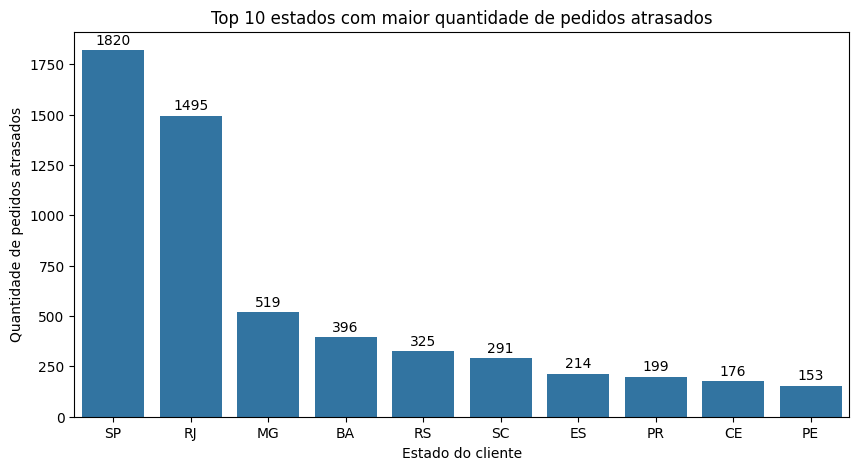

In [49]:
# Visualizando os estados com maior quantidade absoluta de pedidos atrasados

top_volume_atraso_estado = volume_atraso_estado.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_volume_atraso_estado,
    x='customer_state',
    y='pedidos_atrasados'
)

plt.title('Top 10 estados com maior quantidade de pedidos atrasados')
plt.xlabel('Estado do cliente')
plt.ylabel('Quantidade de pedidos atrasados')

for i, valor in enumerate(top_volume_atraso_estado['pedidos_atrasados']):
    plt.text(i, valor + 30, f'{valor:.0f}', ha='center')

plt.show()

O gráfico de volume absoluto de atrasos mostra que SP e RJ concentram a maior quantidade de pedidos entregues fora do prazo. SP aparece com 1.820 pedidos atrasados, seguido por RJ, com 1.495 pedidos atrasados.

Esse resultado precisa ser interpretado junto com o percentual de atraso. SP possui o maior volume absoluto porque também concentra uma quantidade muito elevada de pedidos na base, mas seu percentual de atraso é relativamente baixo. Já o RJ apresenta tanto um volume expressivo de atrasos quanto um percentual elevado, o que indica maior relevância para investigação.

Estados como MG, BA, RS e SC também aparecem entre os maiores volumes de atraso. No entanto, BA se destaca mais do ponto de vista proporcional, pois combina quantidade relevante de atrasos com percentual acima da média geral da base.

Assim, a análise mostra que os estados mais críticos não são necessariamente apenas aqueles com maior percentual de atraso, mas aqueles que combinam volume relevante e proporção elevada de entregas fora do prazo.

## Comparação entre volume e percentual de atraso por estado

Nesta etapa, será criada uma visão consolidada dos estados, considerando simultaneamente a quantidade total de pedidos, a quantidade de pedidos atrasados, o percentual de atraso e a participação de cada estado no total de atrasos da base.

Essa análise permite identificar estados que combinam alto volume absoluto de atrasos com percentual elevado, oferecendo uma visão mais equilibrada do impacto regional no problema analisado.

In [50]:
# Criando uma visão consolidada do impacto dos atrasos por estado

impacto_estado_cliente = atraso_estado_cliente.copy()

impacto_estado_cliente['participacao_atrasos'] = (
    impacto_estado_cliente['pedidos_atrasados'] / impacto_estado_cliente['pedidos_atrasados'].sum() * 100
).round(2)

impacto_estado_cliente = impacto_estado_cliente.sort_values(
    by='pedidos_atrasados',
    ascending=False
)

print('Comparação entre volume, percentual e participação nos atrasos por estado:')
impacto_estado_cliente.head(10)

Comparação entre volume, percentual e participação nos atrasos por estado:


,customer_state,total_pedidos,pedidos_atrasados,percentual_atraso,participacao_atrasos
25,SP,40494,1820,4.49,27.85
18,RJ,12350,1495,12.11,22.88
10,MG,11354,519,4.57,7.94
4,BA,3256,396,12.16,6.06
22,RS,5344,325,6.08,4.97
23,SC,3546,291,8.21,4.45
7,ES,1995,214,10.73,3.28
17,PR,4923,199,4.04,3.05
5,CE,1279,176,13.76,2.69
15,PE,1593,153,9.60,2.34


A tabela consolidada permite comparar o impacto dos atrasos por estado de forma mais equilibrada. Nessa visão, SP aparece como o estado com maior quantidade absoluta de pedidos atrasados, somando 1.820 ocorrências, o que representa 27,85% de todos os atrasos da base. No entanto, seu percentual de atraso é de 4,49%, abaixo da média geral observada.

O RJ se destaca como um estado mais crítico, pois combina alto volume absoluto de atrasos com percentual elevado. O estado registrou 1.495 pedidos atrasados, representando 22,88% dos atrasos da base, e apresentou percentual de atraso de 12,11%.

MG também aparece entre os maiores volumes de atraso, com 519 pedidos atrasados, mas seu percentual de atraso é relativamente baixo, de 4,57%. Esse comportamento indica que o volume de atrasos está mais associado ao grande número de pedidos no estado do que a uma proporção elevada de problemas.

BA, CE e ES merecem atenção por apresentarem percentuais de atraso acima da média geral, mesmo com menor participação absoluta em comparação com SP e RJ. Esses estados podem indicar regiões com maior risco proporcional de atraso.

De forma geral, a análise regional mostra que SP possui o maior impacto em volume, enquanto RJ se destaca por combinar volume elevado e percentual expressivo de atraso. Essa diferença reforça a importância de avaliar os atrasos tanto pela quantidade absoluta quanto pela proporção dentro de cada estado.

## Relação entre volume de pedidos e percentual de atraso

Para complementar a análise regional, será criada uma visualização relacionando o volume total de pedidos com o percentual de atraso por estado. Essa abordagem permite identificar estados que apresentam maior relevância operacional, considerando simultaneamente quantidade de pedidos e proporção de entregas fora do prazo.

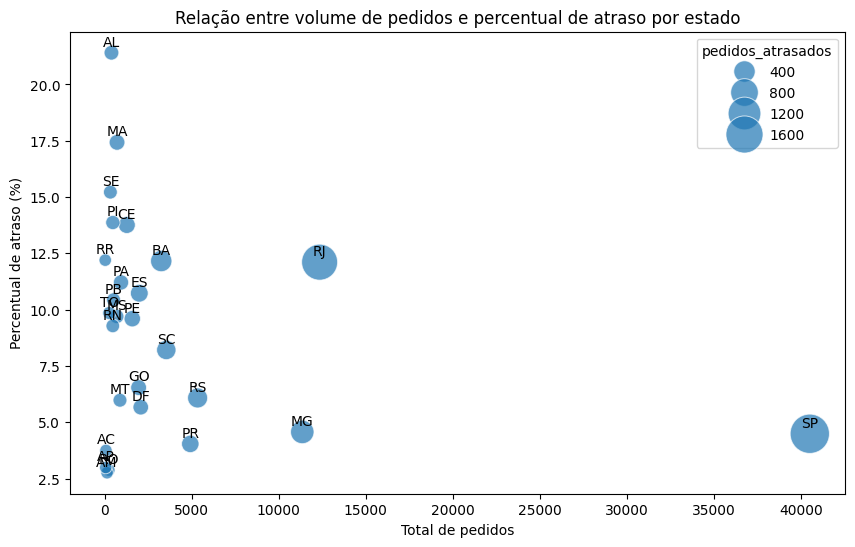

In [51]:
# Visualizando a relação entre volume de pedidos e percentual de atraso por estado

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=impacto_estado_cliente,
    x='total_pedidos',
    y='percentual_atraso',
    size='pedidos_atrasados',
    sizes=(80, 800),
    alpha=0.7
)

for i in range(impacto_estado_cliente.shape[0]):
    plt.text(
        impacto_estado_cliente['total_pedidos'].iloc[i],
        impacto_estado_cliente['percentual_atraso'].iloc[i] + 0.3,
        impacto_estado_cliente['customer_state'].iloc[i],
        ha='center'
    )

plt.title('Relação entre volume de pedidos e percentual de atraso por estado')
plt.xlabel('Total de pedidos')
plt.ylabel('Percentual de atraso (%)')

plt.show()

O gráfico de dispersão relaciona o volume total de pedidos com o percentual de atraso por estado, enquanto o tamanho dos pontos representa a quantidade absoluta de pedidos atrasados.

A visualização confirma que SP possui o maior volume total de pedidos e também a maior quantidade absoluta de atrasos. No entanto, seu percentual de atraso é relativamente baixo, indicando que o número elevado de atrasos está relacionado principalmente ao grande volume operacional do estado.

O RJ se destaca como um dos estados mais críticos da análise, pois combina volume expressivo de pedidos, alta quantidade absoluta de atrasos e percentual de atraso acima da média geral da base. Esse comportamento sugere maior relevância para investigação logística.

Estados como AL, MA, SE, PI e CE aparecem com percentuais de atraso mais elevados, porém com menor volume total de pedidos. Esses casos indicam maior risco proporcional, mas impacto operacional menor quando comparados a estados com grande concentração de pedidos.

De forma geral, a análise mostra que a avaliação regional dos atrasos deve considerar simultaneamente volume e percentual. Enquanto SP representa o maior impacto absoluto, RJ se apresenta como um ponto de atenção mais crítico por combinar volume relevante e proporção elevada de entregas fora do prazo.

## Atraso por estado do vendedor

Após analisar os atrasos considerando o estado do cliente, será avaliado o estado do vendedor. Essa análise permite investigar se determinadas origens de envio apresentam maior relação com entregas fora do prazo.

A comparação entre estado do cliente e estado do vendedor é importante porque o atraso pode estar associado tanto ao destino da entrega quanto à localização de origem do pedido. Dessa forma, esta etapa ajuda a ampliar a compreensão dos possíveis fatores logísticos relacionados ao atraso.

In [52]:
# Analisando o percentual de atraso por estado do vendedor

atraso_estado_vendedor = df.groupby('seller_state').agg(
    total_pedidos=('order_id', 'count'),
    pedidos_atrasados=('atraso', 'sum'),
    percentual_atraso=('atraso', 'mean')
).reset_index()

atraso_estado_vendedor['percentual_atraso'] = (
    atraso_estado_vendedor['percentual_atraso'] * 100
).round(2)

atraso_estado_vendedor = atraso_estado_vendedor.sort_values(
    by='percentual_atraso',
    ascending=False
)

print('Percentual de atraso por estado do vendedor:')
atraso_estado_vendedor.head(10)

Percentual de atraso por estado do vendedor:


,seller_state,total_pedidos,pedidos_atrasados,percentual_atraso
0,AM,3,1,33.33
6,MA,388,74,19.07
16,RN,51,4,7.84
21,SP,68415,5015,7.33
15,RJ,4185,301,7.19
2,CE,85,6,7.06
8,MS,47,3,6.38
4,ES,308,19,6.17
14,PR,7429,402,5.41
3,DF,803,42,5.23


A análise por estado do vendedor mostra que alguns estados apresentam percentuais elevados de atraso. No entanto, essa leitura precisa ser feita com cautela, pois alguns estados possuem baixo volume de pedidos.

O estado AM aparece com o maior percentual de atraso, 33,33%, porém esse resultado está baseado em apenas 3 pedidos. Por esse motivo, esse percentual não deve ser interpretado isoladamente como evidência forte de problema logístico.

Entre os estados com maior volume de pedidos, SP se destaca por concentrar a maior quantidade de pedidos e também o maior número absoluto de atrasos, com 5.015 pedidos atrasados. Apesar disso, seu percentual de atraso é de 7,33%, indicando que o problema está mais relacionado ao grande volume operacional do estado.

O MA também chama atenção, pois apresentou percentual de atraso de 19,07%, com 388 pedidos analisados. Embora o volume seja menor em comparação com SP, o percentual elevado pode indicar uma origem de envio com maior risco proporcional de atraso.

De forma geral, a análise do estado do vendedor mostra que a origem do pedido também pode estar relacionada aos atrasos, mas a interpretação deve considerar simultaneamente o percentual de atraso e o volume total de pedidos.

## Atraso por estado do vendedor com volume mínimo de pedidos

Para evitar interpretações distorcidas por estados com poucos pedidos, será aplicada uma filtragem considerando apenas estados de vendedor com pelo menos 100 pedidos na base.

Essa etapa permite uma comparação mais estável, pois reduz o impacto de percentuais elevados calculados sobre bases muito pequenas.

In [53]:
# Filtrando estados do vendedor com pelo menos 100 pedidos

atraso_estado_vendedor_filtrado = atraso_estado_vendedor[
    atraso_estado_vendedor['total_pedidos'] >= 100
].copy()

atraso_estado_vendedor_filtrado = atraso_estado_vendedor_filtrado.sort_values(
    by='percentual_atraso',
    ascending=False
)

print('Percentual de atraso por estado do vendedor com pelo menos 100 pedidos:')
atraso_estado_vendedor_filtrado.head(10)

Percentual de atraso por estado do vendedor com pelo menos 100 pedidos:


,seller_state,total_pedidos,pedidos_atrasados,percentual_atraso
6,MA,388,74,19.07
21,SP,68415,5015,7.33
15,RJ,4185,301,7.19
4,ES,308,19,6.17
14,PR,7429,402,5.41
3,DF,803,42,5.23
19,SC,3551,175,4.93
1,BA,549,27,4.92
7,MG,7647,370,4.84
9,MT,134,5,3.73


Após aplicar o filtro de pelo menos 100 pedidos por estado do vendedor, a análise se torna mais estável e reduz o impacto de percentuais calculados sobre bases muito pequenas.

Nessa visão, o MA apresenta o maior percentual de atraso, com 19,07% dos pedidos entregues fora do prazo. Embora o volume total de pedidos seja menor em comparação com estados como SP, PR, MG e RJ, o percentual elevado indica uma origem de envio que merece atenção proporcional.

O estado de SP concentra o maior volume de pedidos e também a maior quantidade absoluta de atrasos, com 5.015 pedidos atrasados. No entanto, seu percentual de atraso é de 7,33%, o que indica que o alto número de atrasos está associado principalmente ao grande volume operacional do estado.

RJ também aparece como um ponto relevante, pois combina volume expressivo de pedidos com percentual de atraso de 7,19%. Já PR e MG apresentam grandes volumes de pedidos, mas percentuais menores de atraso em comparação com MA, SP e RJ.

De forma geral, a análise filtrada mostra que MA se destaca pelo risco proporcional, enquanto SP representa o maior impacto absoluto em volume de atrasos. Essa diferença reforça a importância de avaliar os estados dos vendedores tanto pelo percentual quanto pela quantidade de pedidos atrasados.

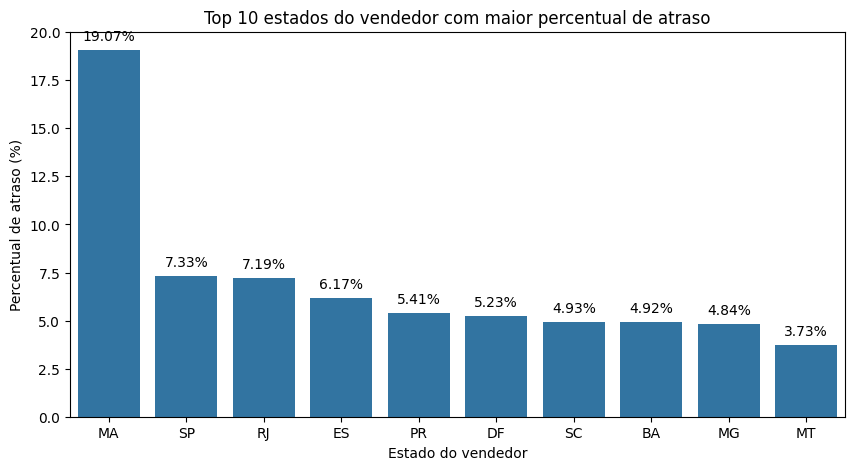

In [54]:
# Visualizando os estados do vendedor com maior percentual de atraso

top_vendedor_percentual = atraso_estado_vendedor_filtrado.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_vendedor_percentual,
    x='seller_state',
    y='percentual_atraso'
)

plt.title('Top 10 estados do vendedor com maior percentual de atraso')
plt.xlabel('Estado do vendedor')
plt.ylabel('Percentual de atraso (%)')

for i, valor in enumerate(top_vendedor_percentual['percentual_atraso']):
    plt.text(i, valor + 0.5, f'{valor:.2f}%', ha='center')

plt.show()

O gráfico mostra os estados do vendedor com maior percentual de atraso, considerando apenas estados com pelo menos 100 pedidos. Essa filtragem torna a comparação mais confiável, pois reduz o efeito de percentuais calculados sobre volumes muito pequenos.

O MA apresenta o maior percentual de atraso, com 19,07% dos pedidos entregues fora do prazo. Esse resultado indica um risco proporcional mais elevado para pedidos originados nesse estado, embora o volume total de pedidos seja menor em comparação com os principais estados vendedores da base.

SP aparece na segunda posição, com 7,33% de atraso. Apesar de o percentual ser bem menor que o do MA, SP concentra um volume muito superior de pedidos e, por isso, representa um impacto operacional relevante na análise.

RJ também se destaca, com 7,19% de atraso, combinando percentual acima de outros estados importantes e volume expressivo de pedidos. Já PR e MG possuem grande participação na base, mas percentuais menores de atraso em comparação com MA, SP e RJ.

De forma geral, a análise por estado do vendedor mostra que MA apresenta o maior risco proporcional, enquanto SP representa o maior impacto absoluto em volume de pedidos atrasados. Assim como na análise por estado do cliente, a avaliação do vendedor também deve considerar simultaneamente percentual e quantidade de atrasos.

## Volume de pedidos atrasados por estado do vendedor

Além do percentual de atraso, é importante avaliar a quantidade absoluta de pedidos atrasados por estado do vendedor. Essa análise permite identificar quais origens concentram o maior volume de problemas operacionais.

Um estado pode apresentar percentual elevado de atraso, mas baixo volume de pedidos. Por outro lado, estados com grande volume de pedidos podem representar maior impacto para o negócio mesmo com percentuais menores.

In [55]:
# Analisando os estados do vendedor com maior quantidade absoluta de pedidos atrasados

volume_atraso_vendedor = atraso_estado_vendedor.sort_values(
    by='pedidos_atrasados',
    ascending=False
)

print('Estados do vendedor com maior quantidade de pedidos atrasados:')
volume_atraso_vendedor.head(10)

Estados do vendedor com maior quantidade de pedidos atrasados:


,seller_state,total_pedidos,pedidos_atrasados,percentual_atraso
21,SP,68415,5015,7.33
14,PR,7429,402,5.41
7,MG,7647,370,4.84
15,RJ,4185,301,7.19
19,SC,3551,175,4.93
6,MA,388,74,19.07
18,RS,1949,61,3.13
3,DF,803,42,5.23
1,BA,549,27,4.92
4,ES,308,19,6.17


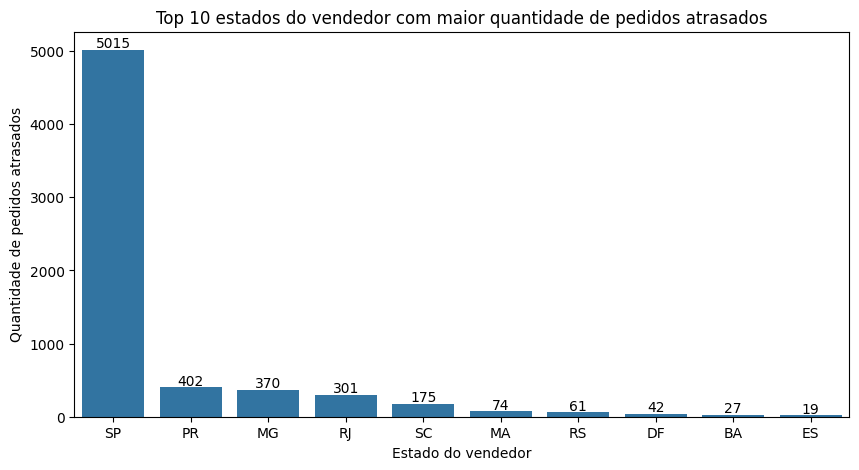

In [56]:
# Visualizando os estados do vendedor com maior quantidade absoluta de pedidos atrasados

top_volume_atraso_vendedor = volume_atraso_vendedor.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_volume_atraso_vendedor,
    x='seller_state',
    y='pedidos_atrasados'
)

plt.title('Top 10 estados do vendedor com maior quantidade de pedidos atrasados')
plt.xlabel('Estado do vendedor')
plt.ylabel('Quantidade de pedidos atrasados')

for i, valor in enumerate(top_volume_atraso_vendedor['pedidos_atrasados']):
    plt.text(i, valor + 30, f'{valor:.0f}', ha='center')

plt.show()

O gráfico mostra que SP concentra a maior quantidade absoluta de pedidos atrasados entre os estados do vendedor, com 5.015 ocorrências. Esse volume é muito superior ao dos demais estados, indicando que SP possui o maior impacto operacional nos atrasos analisados.

Em seguida, aparecem PR, MG e RJ, também com volumes relevantes de pedidos atrasados, embora em escala bem menor quando comparados a SP. Esses estados também merecem atenção na análise, pois contribuem de forma significativa para o total de atrasos.

Por outro lado, estados como MA apresentam menor volume absoluto, mesmo tendo apresentado percentual de atraso elevado na análise anterior. Isso mostra que um percentual alto nem sempre representa o maior impacto operacional, principalmente quando a quantidade total de pedidos é pequena.

De forma geral, a análise confirma que a avaliação dos atrasos por estado do vendedor deve considerar duas perspectivas: o percentual de atraso, que indica o risco proporcional, e a quantidade absoluta de pedidos atrasados, que mostra o impacto total para o negócio.

### Comparação entre estado do cliente e estado do vendedor

Nesta etapa, será analisada a relação entre o estado do cliente e o estado do vendedor. O objetivo é verificar se os atrasos estão mais associados ao destino da entrega, à origem do pedido ou à distância logística entre cliente e vendedor.

Essa análise permite identificar combinações de estados que concentram maior quantidade de atrasos, ajudando a compreender possíveis padrões regionais nas entregas fora do prazo.

In [57]:
# Comparando estado do cliente e estado do vendedor

rota_estado = df.groupby(['seller_state', 'customer_state']).agg(
    total_pedidos=('order_id', 'count'),
    pedidos_atrasados=('atraso', 'sum'),
    percentual_atraso=('atraso', 'mean')
).reset_index()

rota_estado['percentual_atraso'] = (rota_estado['percentual_atraso'] * 100).round(2)

rota_estado = rota_estado.sort_values(
    by='pedidos_atrasados',
    ascending=False
)

print('Combinações de estado do vendedor e cliente com maior quantidade de atrasos:')
rota_estado.head(10)

Combinações de estado do vendedor e cliente com maior quantidade de atrasos:


,seller_state,customer_state,total_pedidos,pedidos_atrasados,percentual_atraso
407,SP,SP,30735,1428,4.65
400,SP,RJ,8158,1152,14.12
392,SP,MG,7440,393,5.28
386,SP,BA,2307,297,12.87
404,SP,RS,3596,238,6.62
405,SP,SC,2327,222,9.54
389,SP,ES,1461,180,12.32
399,SP,PR,3119,138,4.42
387,SP,CE,969,133,13.73
269,PR,RJ,963,117,12.15


A comparação entre o estado do vendedor e o estado do cliente mostra que as combinações com maior quantidade absoluta de atrasos envolvem principalmente vendedores localizados em SP. A rota SP → SP concentrou o maior volume de pedidos atrasados, com 1.428 ocorrências, porém o percentual de atraso foi de 4,65%, relativamente baixo quando comparado a outras rotas.

Já a rota SP → RJ apresentou 1.152 pedidos atrasados e percentual de atraso de 14,12%, indicando uma combinação mais crítica, pois reúne volume expressivo de atrasos e proporção elevada de entregas fora do prazo.

Também se destacam as rotas SP → MG, SP → BA, SP → SC, SP → ES e SP → CE, que apresentam volumes relevantes de atrasos e percentuais acima da média geral da base. Esse resultado sugere que parte importante dos atrasos pode estar relacionada a rotas interestaduais com origem em SP, especialmente quando o destino está em estados mais distantes ou com maior complexidade logística.

De forma geral, a análise indica que SP aparece como principal origem dos pedidos atrasados em termos absolutos, mas a interpretação deve considerar que esse estado também concentra grande volume operacional. Por isso, as rotas com percentual de atraso mais elevado, como SP → RJ, SP → CE, SP → BA e PR → RJ, merecem atenção especial nas próximas etapas da análise.

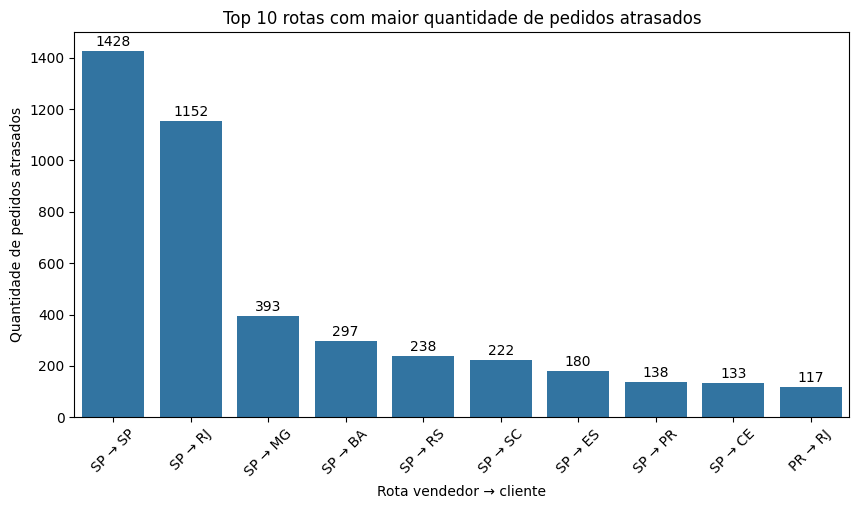

In [58]:
# Visualizando as combinações de estado com maior quantidade de atrasos

top_rotas_atraso = rota_estado.head(10).copy()

top_rotas_atraso['rota'] = (
    top_rotas_atraso['seller_state'] + ' → ' + top_rotas_atraso['customer_state']
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_rotas_atraso,
    x='rota',
    y='pedidos_atrasados'
)

plt.title('Top 10 rotas com maior quantidade de pedidos atrasados')
plt.xlabel('Rota vendedor → cliente')
plt.ylabel('Quantidade de pedidos atrasados')

for i, valor in enumerate(top_rotas_atraso['pedidos_atrasados']):
    plt.text(i, valor + 20, f'{valor:.0f}', ha='center')

plt.xticks(rotation=45)
plt.show()

O gráfico mostra que as rotas com maior quantidade absoluta de pedidos atrasados possuem, em sua maioria, origem no estado de SP. A rota SP → SP concentra o maior volume de atrasos, com 1.428 ocorrências, seguida pela rota SP → RJ, com 1.152 pedidos atrasados.

Apesar de SP → SP apresentar o maior volume absoluto, essa rota também possui grande quantidade total de pedidos, o que reduz seu percentual de atraso em comparação com outras combinações. Já a rota SP → RJ merece maior atenção, pois combina volume elevado de atrasos com percentual também expressivo.

As rotas SP → MG, SP → BA, SP → RS, SP → SC, SP → ES, SP → PR e SP → CE também aparecem entre as principais combinações com atraso, reforçando que parte relevante dos atrasos está associada a pedidos com origem em SP e destino para outros estados.

De forma geral, essa análise mostra que o volume absoluto de atrasos está fortemente concentrado em poucas rotas, especialmente nas rotas originadas em SP. No entanto, para uma interpretação mais equilibrada, é importante complementar essa visão com o percentual de atraso por rota, evitando concluir apenas com base na quantidade total de pedidos atrasados.

In [59]:
# Analisando rotas com maior percentual de atraso, considerando apenas rotas com pelo menos 100 pedidos

rota_estado_filtrada = rota_estado[rota_estado['total_pedidos'] >= 100].copy()

rota_estado_percentual = rota_estado_filtrada.sort_values(
    by='percentual_atraso',
    ascending=False
)

print('Rotas com maior percentual de atraso considerando pelo menos 100 pedidos:')
rota_estado_percentual.head(10)

Rotas com maior percentual de atraso considerando pelo menos 100 pedidos:


,seller_state,customer_state,total_pedidos,pedidos_atrasados,percentual_atraso
383,SP,AL,255,61,23.92
141,MA,SP,123,25,20.33
391,SP,MA,491,93,18.94
398,SP,PI,329,54,16.41
406,SP,SE,208,34,16.35
255,PR,BA,143,21,14.69
400,SP,RJ,8158,1152,14.12
387,SP,CE,969,133,13.73
386,SP,BA,2307,297,12.87
393,SP,MS,477,59,12.37


Ao considerar apenas rotas com pelo menos 100 pedidos, a análise percentual se torna mais estável e reduz o risco de interpretações distorcidas por bases muito pequenas.

A rota SP → AL apresentou o maior percentual de atraso, com 23,92% dos pedidos entregues fora do prazo. Em seguida, aparecem as rotas MA → SP, com 20,33%, e SP → MA, com 18,94%. Esses resultados indicam que algumas rotas específicas apresentam maior risco proporcional de atraso, mesmo não sendo necessariamente as rotas com maior volume absoluto de pedidos atrasados.

Também se destacam as rotas SP → PI, SP → SE, PR → BA, SP → RJ, SP → CE, SP → BA e SP → MS, todas com percentuais de atraso superiores à média geral da base. A rota SP → RJ merece atenção especial, pois já havia aparecido entre as maiores em volume absoluto de atrasos e também apresenta percentual elevado.

De forma geral, essa análise mostra que os atrasos não devem ser avaliados apenas pela quantidade absoluta de pedidos atrasados. Algumas rotas possuem menor volume total, mas apresentam maior proporção de entregas fora do prazo, indicando possíveis problemas logísticos específicos nessas combinações de origem e destino.

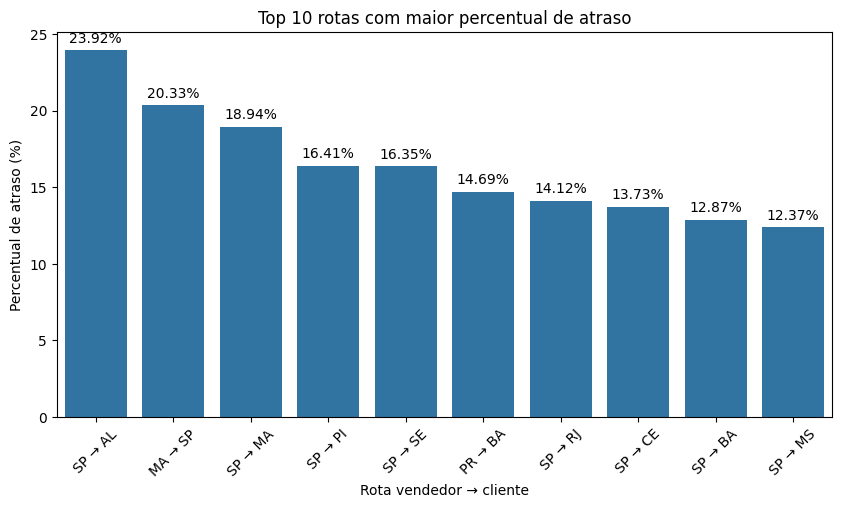

In [60]:
# Visualizando as rotas com maior percentual de atraso

top_rotas_percentual = rota_estado_percentual.head(10).copy()

top_rotas_percentual['rota'] = (
    top_rotas_percentual['seller_state'] + ' → ' + top_rotas_percentual['customer_state']
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_rotas_percentual,
    x='rota',
    y='percentual_atraso'
)

plt.title('Top 10 rotas com maior percentual de atraso')
plt.xlabel('Rota vendedor → cliente')
plt.ylabel('Percentual de atraso (%)')

for i, valor in enumerate(top_rotas_percentual['percentual_atraso']):
    plt.text(i, valor + 0.5, f'{valor:.2f}%', ha='center')

plt.xticks(rotation=45)
plt.show()

O gráfico mostra que, entre as rotas com pelo menos 100 pedidos, a rota SP → AL apresentou o maior percentual de atraso, com 23,92% dos pedidos entregues fora do prazo. Em seguida, aparecem as rotas MA → SP, com 20,33%, e SP → MA, com 18,94%.

Também se destacam as rotas SP → PI, SP → SE, PR → BA, SP → RJ, SP → CE, SP → BA e SP → MS, todas com percentuais de atraso superiores à média geral da base. Esses resultados indicam que algumas combinações específicas de origem e destino possuem maior risco proporcional de atraso.

A rota SP → RJ merece atenção especial, pois apareceu tanto entre as maiores em volume absoluto de atrasos quanto entre as rotas com maior percentual de atraso. Isso sugere que essa rota pode ser de maior relevância operacional para a análise.

De forma geral, essa visualização reforça que os atrasos não devem ser avaliados apenas pela quantidade absoluta de pedidos atrasados. Algumas rotas possuem menor volume, mas apresentam maior proporção de entregas fora do prazo, indicando possíveis problemas logísticos específicos nessas combinações.

### Atraso por categoria de produto

Nesta etapa, será analisada a relação entre a categoria do produto e os atrasos nas entregas. Como diferentes categorias podem ter características logísticas distintas, essa análise permite verificar se determinados tipos de produto apresentam maior proporção ou maior quantidade de pedidos entregues fora do prazo.

Assim como nas análises regionais, será considerada tanto a quantidade absoluta de pedidos atrasados quanto o percentual de atraso por categoria, evitando conclusões baseadas apenas em proporções de categorias com baixo volume de pedidos.

In [61]:
# Analisando o percentual de atraso por categoria do produto

atraso_categoria = df.groupby('product_category_name_english').agg(
    total_pedidos=('order_id', 'count'),
    pedidos_atrasados=('atraso', 'sum'),
    percentual_atraso=('atraso', 'mean')
).reset_index()

atraso_categoria['percentual_atraso'] = (
    atraso_categoria['percentual_atraso'] * 100
).round(2)

atraso_categoria = atraso_categoria.sort_values(
    by='percentual_atraso',
    ascending=False
)

print('Categorias com maior percentual de atraso:')
atraso_categoria.head(10)

Categorias com maior percentual de atraso:


,product_category_name_english,total_pedidos,pedidos_atrasados,percentual_atraso
46,home_comfort_2,22,3,13.64
41,furniture_mattress_and_upholstery,37,5,13.51
4,audio,344,41,11.92
47,home_confort,370,35,9.46
33,fashion_underwear_beach,117,11,9.40
10,books_technical,255,21,8.24
6,baby,2763,226,8.18
57,office_furniture,1246,101,8.11
12,christmas_supplies,125,10,8.00
26,electronics,2507,192,7.66


A análise por categoria de produto mostra que algumas categorias apresentam percentuais de atraso superiores à média geral da base. As maiores proporções aparecem em categorias como `home_comfort_2`, `furniture_mattress_and_upholstery` e `audio`.

No entanto, é importante interpretar esses resultados com cautela, pois as duas primeiras categorias possuem baixo volume de pedidos, com 22 e 37 registros, respectivamente. Dessa forma, pequenos aumentos na quantidade de atrasos podem gerar percentuais elevados.

Entre as categorias com maior volume, destacam-se `baby`, `office_furniture` e `electronics`, que apresentam quantidades mais expressivas de pedidos e também registram atrasos relevantes. Por isso, a análise de categoria deve considerar tanto o percentual de atraso quanto a quantidade absoluta de pedidos atrasados.

In [62]:
# Analisando as categorias com maior quantidade absoluta de pedidos atrasados

volume_atraso_categoria = atraso_categoria.sort_values(
    by='pedidos_atrasados',
    ascending=False
)

print('Categorias com maior quantidade de pedidos atrasados:')
volume_atraso_categoria.head(10)

Categorias com maior quantidade de pedidos atrasados:


,product_category_name_english,total_pedidos,pedidos_atrasados,percentual_atraso
7,bed_bath_table,9171,689,7.51
43,health_beauty,8608,649,7.54
66,sports_leisure,7492,495,6.61
39,furniture_decor,6213,446,7.18
15,computers_accessories,6501,417,6.41
71,watches_gifts,5470,406,7.42
49,housewares,5695,307,5.39
69,telephony,4076,291,7.14
5,auto,3793,278,7.33
70,toys,3779,241,6.38


A análise da quantidade absoluta de pedidos atrasados por categoria mostra que as categorias com maior volume de atrasos são `bed_bath_table`, `health_beauty`, `sports_leisure`, `furniture_decor` e `computers_accessories`.

Diferentemente da análise percentual, essas categorias possuem volumes de pedidos muito mais expressivos. Por isso, mesmo com percentuais de atraso próximos ou pouco acima da média geral da base, elas concentram uma quantidade maior de ocorrências de atraso.

A categoria `bed_bath_table` apresenta o maior número absoluto de pedidos atrasados, com 689 ocorrências, seguida por `health_beauty`, com 649 atrasos. Essas categorias merecem maior atenção operacional, pois representam maior impacto no volume total de entregas fora do prazo.

Assim, a análise por categoria confirma a importância de avaliar os atrasos por duas perspectivas: o percentual de atraso, que indica risco proporcional, e a quantidade absoluta de atrasos, que indica impacto operacional.

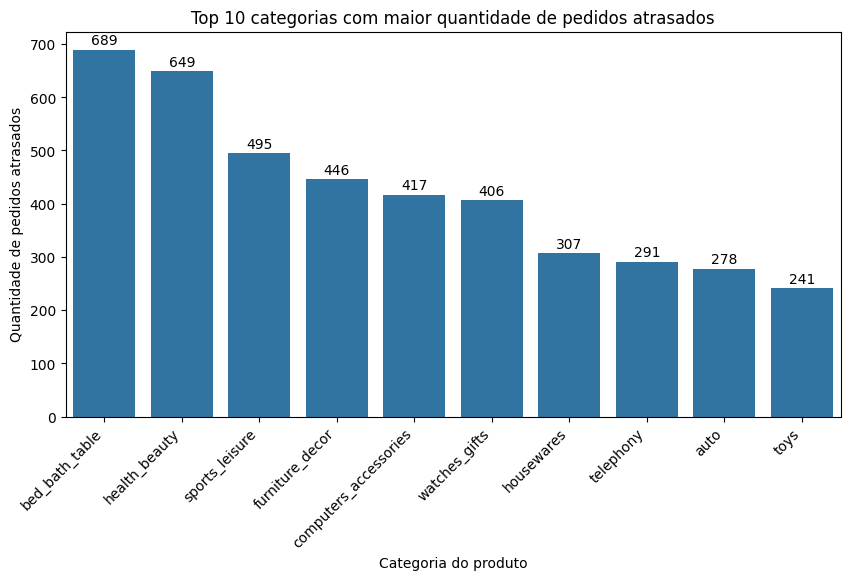

In [63]:
# Visualizando as categorias com maior quantidade absoluta de pedidos atrasados

top_volume_categoria = volume_atraso_categoria.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_volume_categoria,
    x='product_category_name_english',
    y='pedidos_atrasados'
)

plt.title('Top 10 categorias com maior quantidade de pedidos atrasados')
plt.xlabel('Categoria do produto')
plt.ylabel('Quantidade de pedidos atrasados')

for i, valor in enumerate(top_volume_categoria['pedidos_atrasados']):
    plt.text(i, valor + 10, f'{valor:.0f}', ha='center')

plt.xticks(rotation=45, ha='right')
plt.show()

O gráfico confirma que os pedidos atrasados por categoria estão mais concentrados em categorias com grande volume de pedidos. A categoria `bed_bath_table` apresentou a maior quantidade absoluta de pedidos atrasados, com 689 ocorrências, seguida por `health_beauty`, com 649 atrasos.

Também aparecem com volumes relevantes as categorias `sports_leisure`, `furniture_decor`, `computers_accessories` e `watches_gifts`. Esses resultados indicam que, embora o percentual de atraso seja importante para medir o risco proporcional, o volume absoluto mostra quais categorias geram maior impacto operacional na base.

Dessa forma, as categorias com maior quantidade de pedidos atrasados devem receber atenção especial em análises posteriores, pois concentram uma parcela relevante dos problemas de entrega fora do prazo.

## Comparação entre volume e percentual de atraso por categoria

Nesta etapa, será feita uma comparação entre o volume total de pedidos, a quantidade absoluta de pedidos atrasados e o percentual de atraso por categoria. Essa análise permite avaliar as categorias de forma mais equilibrada, considerando tanto o impacto operacional quanto o risco proporcional de atraso.

In [64]:
# Criando uma visão consolidada do impacto dos atrasos por categoria

impacto_categoria = atraso_categoria.copy()

impacto_categoria['participacao_atrasos'] = (
    impacto_categoria['pedidos_atrasados'] / impacto_categoria['pedidos_atrasados'].sum() * 100
).round(2)

impacto_categoria = impacto_categoria.sort_values(
    by='pedidos_atrasados',
    ascending=False
)

print('Comparação entre volume, percentual e participação nos atrasos por categoria:')
impacto_categoria.head(10)

Comparação entre volume, percentual e participação nos atrasos por categoria:


,product_category_name_english,total_pedidos,pedidos_atrasados,percentual_atraso,participacao_atrasos
7,bed_bath_table,9171,689,7.51,10.54
43,health_beauty,8608,649,7.54,9.93
66,sports_leisure,7492,495,6.61,7.58
39,furniture_decor,6213,446,7.18,6.83
15,computers_accessories,6501,417,6.41,6.38
71,watches_gifts,5470,406,7.42,6.21
49,housewares,5695,307,5.39,4.70
69,telephony,4076,291,7.14,4.45
5,auto,3793,278,7.33,4.25
70,toys,3779,241,6.38,3.69


A tabela consolidada mostra que as categorias com maior quantidade absoluta de atrasos também possuem grande volume total de pedidos. A categoria `bed_bath_table` aparece como a principal em impacto operacional, com 689 pedidos atrasados, representando 10,54% de todos os atrasos da base. Em seguida, aparece `health_beauty`, com 649 atrasos e participação de 9,93%.

Categorias como `sports_leisure`, `furniture_decor`, `computers_accessories` e `watches_gifts` também apresentam participação relevante nos atrasos, mesmo com percentuais de atraso relativamente próximos entre si. Isso indica que o impacto dessas categorias está mais relacionado ao volume de pedidos do que somente ao risco proporcional.

Dessa forma, a análise confirma que a priorização das categorias deve considerar tanto o percentual de atraso quanto a quantidade absoluta de pedidos atrasados, pois categorias com grande volume podem gerar maior impacto operacional mesmo quando o percentual de atraso não é o mais elevado.

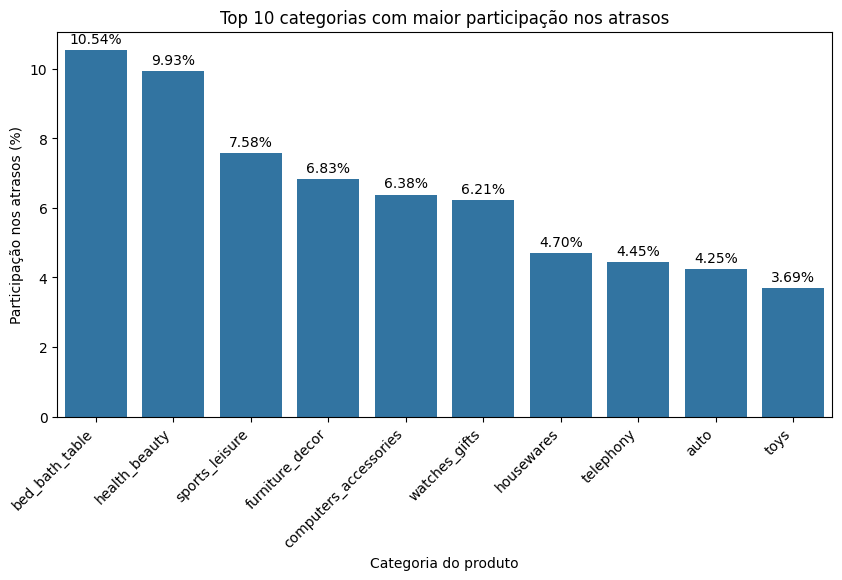

In [65]:
# Visualizando as categorias com maior participação nos atrasos

top_impacto_categoria = impacto_categoria.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_impacto_categoria,
    x='product_category_name_english',
    y='participacao_atrasos'
)

plt.title('Top 10 categorias com maior participação nos atrasos')
plt.xlabel('Categoria do produto')
plt.ylabel('Participação nos atrasos (%)')

for i, valor in enumerate(top_impacto_categoria['participacao_atrasos']):
    plt.text(i, valor + 0.2, f'{valor:.2f}%', ha='center')

plt.xticks(rotation=45, ha='right')
plt.show()

O gráfico mostra que a categoria `bed_bath_table` possui a maior participação nos atrasos da base, representando 10,54% do total de pedidos atrasados. Em seguida, aparece `health_beauty`, com 9,93%, seguida por `sports_leisure`, `furniture_decor`, `computers_accessories` e `watches_gifts`.

Essa visualização reforça que o impacto operacional dos atrasos está concentrado principalmente em categorias com grande volume de pedidos. Mesmo que algumas categorias não apresentem o maior percentual de atraso individualmente, elas contribuem de forma significativa para o total de atrasos por concentrarem muitos pedidos na base.

Dessa forma, as categorias `bed_bath_table`, `health_beauty`, `sports_leisure`, `furniture_decor`, `computers_accessories` e `watches_gifts` devem receber atenção especial nas próximas análises, pois representam uma parcela relevante dos atrasos totais.

### Comparação consolidada dos atrasos por categoria

Após analisar separadamente o percentual de atraso, a quantidade absoluta de pedidos atrasados e a participação de cada categoria no total de atrasos, será criada uma visão consolidada dessas informações.

Essa comparação permite avaliar as categorias de forma mais equilibrada, considerando tanto o risco proporcional de atraso quanto o impacto operacional gerado pelo volume de pedidos atrasados.

In [66]:
# Criando visão consolidada dos atrasos por categoria

categoria_consolidada = impacto_categoria.copy()

categoria_consolidada = categoria_consolidada.sort_values(
    by='pedidos_atrasados',
    ascending=False
)

print('Comparação consolidada dos atrasos por categoria:')
categoria_consolidada.head(10)

Comparação consolidada dos atrasos por categoria:


,product_category_name_english,total_pedidos,pedidos_atrasados,percentual_atraso,participacao_atrasos
7,bed_bath_table,9171,689,7.51,10.54
43,health_beauty,8608,649,7.54,9.93
66,sports_leisure,7492,495,6.61,7.58
39,furniture_decor,6213,446,7.18,6.83
15,computers_accessories,6501,417,6.41,6.38
71,watches_gifts,5470,406,7.42,6.21
49,housewares,5695,307,5.39,4.70
69,telephony,4076,291,7.14,4.45
5,auto,3793,278,7.33,4.25
70,toys,3779,241,6.38,3.69


A comparação consolidada dos atrasos por categoria mostra que os atrasos estão concentrados principalmente em categorias com grande volume de pedidos. A categoria `bed_bath_table` apresentou a maior quantidade absoluta de pedidos atrasados, com 689 ocorrências, representando 10,54% de todos os atrasos da base. Em seguida, aparece `health_beauty`, com 649 atrasos e participação de 9,93%.

Também se destacam as categorias `sports_leisure`, `furniture_decor`, `computers_accessories` e `watches_gifts`, que combinam volume relevante de pedidos com participação expressiva no total de atrasos.

Essa análise reforça que a priorização das categorias deve considerar não apenas o percentual de atraso, mas também o impacto operacional causado pela quantidade absoluta de pedidos atrasados. Dessa forma, categorias com grande volume podem representar maior impacto para o negócio, mesmo quando o percentual de atraso não é o mais elevado.

## Análise do valor dos pedidos e do frete

Nesta etapa, serão analisadas as variáveis relacionadas ao valor dos produtos e ao valor do frete. O objetivo é verificar se pedidos com valores mais altos ou fretes mais elevados apresentam comportamento diferente em relação aos atrasos.

Essa análise é importante porque o valor do pedido e o custo do frete podem estar associados a fatores logísticos, como tipo de produto, distância de entrega, complexidade operacional ou modalidade de envio.

In [67]:
# Estatísticas descritivas dos valores dos produtos e do frete

valor_frete_desc = df[['valor_produtos', 'valor_frete']].describe().T.reset_index()

valor_frete_desc.columns = ['Variável', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']

print('Estatísticas descritivas dos valores dos produtos e do frete:')
valor_frete_desc

Estatísticas descritivas dos valores dos produtos e do frete:


,Variável,count,mean,std,min,25%,50%,75%,max
0,valor_produtos,96470.00,137.04,209.05,0.85,45.90,86.50,149.90,13440.00
1,valor_frete,96470.00,22.79,21.56,0.00,13.85,17.17,24.02,1794.96


As estatísticas descritivas mostram que o valor médio dos produtos por pedido foi de aproximadamente 137,04, enquanto a mediana foi de 86,50. Essa diferença entre média e mediana indica assimetria à direita, ou seja, a maior parte dos pedidos possui valores mais baixos, mas existem pedidos com valores muito elevados que aumentam a média.

O valor máximo dos produtos chegou a 13.440,00, reforçando a presença de valores extremos na base. Por esse motivo, a análise gráfica deve considerar a possibilidade de outliers, para evitar que poucos pedidos de valor muito alto distorçam a interpretação geral.

Em relação ao frete, o valor médio foi de aproximadamente 22,79, enquanto a mediana foi de 17,17. Assim como no valor dos produtos, o frete também apresenta assimetria à direita, com alguns valores muito elevados, chegando ao máximo de 1.794,96.

De forma geral, tanto o valor dos produtos quanto o valor do frete apresentam dispersão relevante e presença de valores extremos. Por isso, nas próximas análises será importante comparar esses valores entre pedidos entregues dentro do prazo e pedidos com atraso, verificando se há diferença de comportamento entre os grupos.

## Valor dos produtos e frete por situação de atraso

Após analisar as estatísticas gerais de valor dos produtos e valor do frete, será feita uma comparação dessas variáveis entre pedidos entregues dentro do prazo e pedidos com atraso.

Essa análise permite verificar se os pedidos atrasados apresentam, em média, valores de produto ou frete diferentes dos pedidos entregues dentro do prazo.

In [68]:
# Comparando valor dos produtos e frete por situação de atraso

valor_frete_atraso = df.groupby('atraso')[['valor_produtos', 'valor_frete']].describe().reset_index()

valor_frete_atraso['Situação'] = valor_frete_atraso['atraso'].map({
    0: 'Dentro do prazo',
    1: 'Com atraso'
})

print('Estatísticas de valor dos produtos e frete por situação de atraso:')
valor_frete_atraso

Estatísticas de valor dos produtos e frete por situação de atraso:


atraso valor_produtos                                                 \
                  count   mean    std  min   25%   50%    75%      max   
0      0       89936.00 136.03 207.44 0.85 45.90 85.39 149.90 13440.00   
1      1        6534.00 150.89 229.63 3.54 49.90 90.05 159.99  6729.00   

  valor_frete                                                    Situação  
        count  mean   std  min   25%   50%   75%     max                   
0    89936.00 22.61 21.38 0.00 13.71 17.06 23.85 1794.96  Dentro do prazo  
1     6534.00 25.25 23.72 0.00 15.10 18.23 26.90  711.33       Com atraso

In [69]:
# Comparando médias e medianas de valor dos produtos e frete por situação de atraso

valor_frete_atraso = df.groupby('atraso').agg(
    media_valor_produtos=('valor_produtos', 'mean'),
    mediana_valor_produtos=('valor_produtos', 'median'),
    media_valor_frete=('valor_frete', 'mean'),
    mediana_valor_frete=('valor_frete', 'median'),
    total_pedidos=('order_id', 'count')
).reset_index()

valor_frete_atraso['Situação'] = valor_frete_atraso['atraso'].map({
    0: 'Dentro do prazo',
    1: 'Com atraso'
})

valor_frete_atraso = valor_frete_atraso[
    ['Situação', 'total_pedidos', 'media_valor_produtos', 'mediana_valor_produtos',
     'media_valor_frete', 'mediana_valor_frete']
].round(2)

print('Comparação de valor dos produtos e frete por situação de atraso:')
valor_frete_atraso

Comparação de valor dos produtos e frete por situação de atraso:


,Situação,total_pedidos,media_valor_produtos,mediana_valor_produtos,media_valor_frete,mediana_valor_frete
0,Dentro do prazo,89936,136.03,85.39,22.61,17.06
1,Com atraso,6534,150.89,90.05,25.25,18.23


A comparação entre pedidos entregues dentro do prazo e pedidos com atraso mostra que os pedidos atrasados apresentam valores médios e medianos um pouco superiores tanto para o valor dos produtos quanto para o valor do frete.

Nos pedidos dentro do prazo, a média do valor dos produtos foi de 136,03, com mediana de 85,39. Já nos pedidos com atraso, a média foi de 150,89, com mediana de 90,05. Essa diferença indica que pedidos atrasados tendem a apresentar valores de produtos ligeiramente maiores, embora a diferença não seja extremamente elevada.

Em relação ao frete, os pedidos dentro do prazo apresentaram média de 22,61 e mediana de 17,06. Nos pedidos com atraso, a média foi de 25,25 e a mediana de 18,23. Isso sugere que pedidos com atraso também possuem fretes um pouco mais altos, o que pode estar relacionado a distância, complexidade logística ou características específicas dos pedidos.

De forma geral, os resultados indicam que valor dos produtos e valor do frete podem ter alguma relação com o atraso, mas a diferença entre os grupos não parece ser tão forte isoladamente. Por isso, essas variáveis devem ser analisadas em conjunto com outros fatores, como região, categoria do produto, rota logística e estado do vendedor.

## Visualização dos valores por situação de atraso

Para complementar a comparação numérica, serão utilizados gráficos de boxplot para visualizar a distribuição do valor dos produtos e do valor do frete entre pedidos dentro do prazo e pedidos com atraso.

Como essas variáveis apresentam valores extremos, o boxplot ajuda a observar a mediana, a dispersão e a presença de outliers em cada grupo.

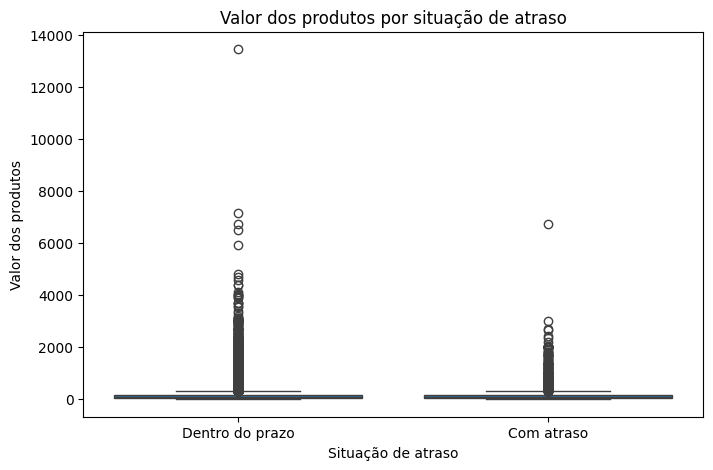

In [70]:
# Visualizando o valor dos produtos por situação de atraso

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='atraso',
    y='valor_produtos'
)

plt.title('Valor dos produtos por situação de atraso')
plt.xlabel('Situação de atraso')
plt.ylabel('Valor dos produtos')

plt.xticks(
    ticks=[0, 1],
    labels=['Dentro do prazo', 'Com atraso']
)

plt.show()

O boxplot do valor dos produtos por situação de atraso mostra que a maior parte dos pedidos está concentrada em valores mais baixos, tanto nos pedidos dentro do prazo quanto nos pedidos com atraso.

Também é possível observar a presença de muitos valores extremos, principalmente nos pedidos entregues dentro do prazo. Esses valores elevados fazem com que a escala do gráfico fique muito ampla, dificultando a visualização da diferença entre as distribuições principais dos dois grupos.

Apesar disso, o gráfico confirma que os dois grupos apresentam assimetria à direita, ou seja, a maior parte dos pedidos possui valores menores, enquanto poucos pedidos apresentam valores muito altos. Por esse motivo, será feita uma nova visualização limitando os dados até o percentil 95, apenas para melhorar a leitura gráfica.

## Visualização do valor dos produtos até o percentil 95

Como o valor dos produtos apresenta valores extremos, será criada uma visualização considerando apenas os pedidos até o percentil 95. Essa etapa não remove definitivamente os dados da base, apenas facilita a interpretação visual da distribuição principal.

Percentil 95 do valor dos produtos: 399.0


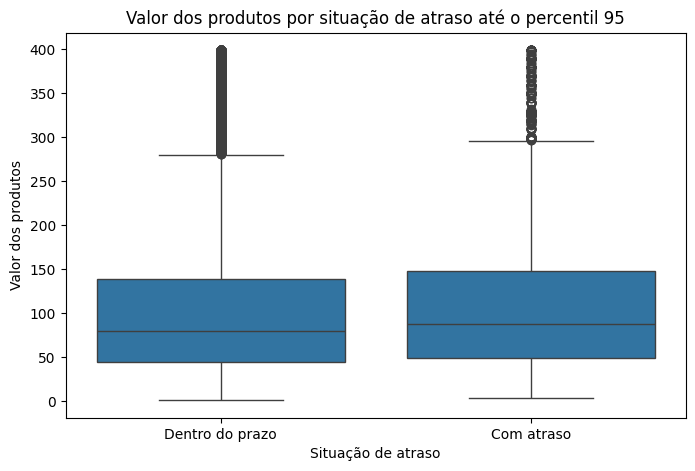

In [71]:
# Visualizando o valor dos produtos até o percentil 95

limite_valor_produtos = df['valor_produtos'].quantile(0.95)

df_valor_produtos_95 = df[df['valor_produtos'] <= limite_valor_produtos]

print('Percentil 95 do valor dos produtos:', limite_valor_produtos)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_valor_produtos_95,
    x='atraso',
    y='valor_produtos'
)

plt.title('Valor dos produtos por situação de atraso até o percentil 95')
plt.xlabel('Situação de atraso')
plt.ylabel('Valor dos produtos')

plt.xticks(
    ticks=[0, 1],
    labels=['Dentro do prazo', 'Com atraso']
)

plt.show()

Ao limitar a visualização ao percentil 95, é possível observar melhor a distribuição principal dos valores dos produtos, sem que os valores extremos dominem a escala do gráfico.

O gráfico mostra que os pedidos com atraso apresentam uma mediana levemente superior em relação aos pedidos dentro do prazo. Também é possível observar que ambos os grupos ainda possuem valores mais altos dentro do recorte analisado, indicando assimetria à direita.

Essa comparação sugere que pedidos com atraso tendem a apresentar valores de produto um pouco maiores, porém a diferença entre os grupos não é suficiente, isoladamente, para explicar os atrasos. Portanto, o valor do produto deve ser analisado em conjunto com outras variáveis, como frete, categoria do produto, rota logística e estado do vendedor.

### Visualização do valor do frete até o percentil 95

Como o valor do frete também apresenta valores extremos, será criada uma visualização complementar considerando apenas os pedidos até o percentil 95. Essa análise permite observar melhor a distribuição principal do frete entre pedidos dentro do prazo e pedidos com atraso, sem remover definitivamente os dados originais da base.

Percentil 95 do valor do frete: 54.78


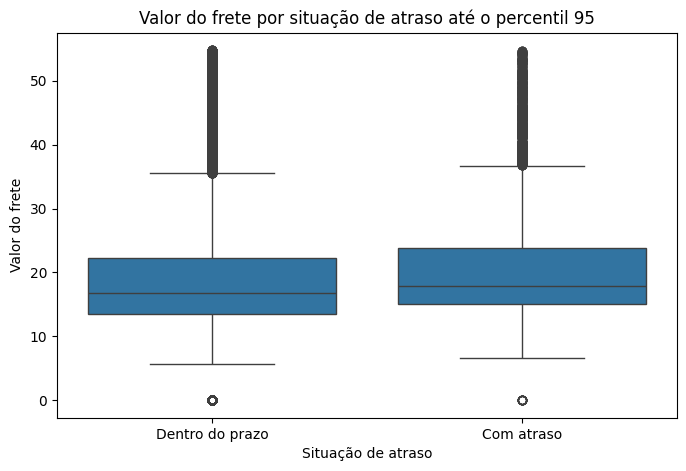

In [72]:
# Visualizando o valor do frete até o percentil 95

limite_valor_frete = df['valor_frete'].quantile(0.95)

df_valor_frete_95 = df[df['valor_frete'] <= limite_valor_frete]

print('Percentil 95 do valor do frete:', limite_valor_frete)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_valor_frete_95,
    x='atraso',
    y='valor_frete'
)

plt.title('Valor do frete por situação de atraso até o percentil 95')
plt.xlabel('Situação de atraso')
plt.ylabel('Valor do frete')

plt.xticks(
    ticks=[0, 1],
    labels=['Dentro do prazo', 'Com atraso']
)

plt.show()

Ao limitar a visualização do valor do frete ao percentil 95, é possível observar melhor a distribuição principal da variável, sem que os valores extremos mais altos dominem a escala do gráfico.

O gráfico mostra que os pedidos com atraso apresentam mediana e dispersão levemente superiores em relação aos pedidos dentro do prazo. Isso indica que, dentro do recorte analisado, os pedidos atrasados tendem a ter fretes um pouco mais elevados.

Mesmo com a limitação ao percentil 95, ainda existem valores acima da faixa principal da distribuição, o que confirma a presença de assimetria à direita. No entanto, a diferença entre os grupos não é muito acentuada, sugerindo que o valor do frete pode estar associado ao atraso, mas não deve ser analisado de forma isolada.

Assim, o frete deve ser considerado em conjunto com outras variáveis logísticas, como estado do cliente, estado do vendedor, rota de entrega, categoria do produto e tempo de entrega.

### Síntese da análise de valor dos produtos e frete

Após analisar o valor dos produtos e o valor do frete, é possível consolidar os principais achados relacionados ao comportamento financeiro dos pedidos e sua possível relação com os atrasos.

A análise mostrou que tanto o valor dos produtos quanto o valor do frete apresentam assimetria à direita, com presença de valores extremos. Por esse motivo, além da visualização geral, foram criadas visualizações limitadas ao percentil 95, permitindo uma comparação mais clara entre pedidos dentro do prazo e pedidos com atraso.

Nos dois casos, os pedidos com atraso apresentaram valores medianos um pouco superiores aos pedidos entregues dentro do prazo. Essa diferença sugere uma possível relação entre valores mais altos, maior complexidade logística e maior chance de atraso.

No entanto, a diferença observada entre os grupos não é suficientemente forte para explicar os atrasos de forma isolada. Dessa forma, valor dos produtos e frete devem ser interpretados como variáveis complementares dentro da análise, em conjunto com fatores regionais, categoria do produto, rota logística e características dos vendedores.

## Análise das avaliações dos clientes

Nesta etapa, será analisada a relação entre a nota de avaliação do cliente e a situação de atraso dos pedidos. A variável `review_score` representa a nota atribuída pelo cliente após a compra, podendo indicar se pedidos entregues fora do prazo tendem a receber avaliações mais baixas.

Essa análise é importante porque o atraso na entrega pode impactar diretamente a percepção de qualidade do serviço, mesmo quando outros fatores, como produto e preço, estejam adequados.

In [73]:
# Comparando as avaliações dos clientes por situação de atraso

avaliacao_atraso = df.groupby('atraso')['review_score'].describe().reset_index()

avaliacao_atraso['Situação'] = avaliacao_atraso['atraso'].map({
    0: 'Dentro do prazo',
    1: 'Com atraso'
})

avaliacao_atraso = avaliacao_atraso[
    ['Situação', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
].round(2)

print('Estatísticas das avaliações por situação de atraso:')
avaliacao_atraso

Estatísticas das avaliações por situação de atraso:


,Situação,count,mean,std,min,25%,50%,75%,max
0,Dentro do prazo,89443.00,4.29,1.15,1.00,4.00,5.00,5.00,5.00
1,Com atraso,6381.00,2.27,1.57,1.00,1.00,1.00,4.00,5.00


A comparação das avaliações por situação de atraso mostra uma diferença expressiva entre os pedidos entregues dentro do prazo e os pedidos com atraso.

Os pedidos entregues dentro do prazo apresentaram média de avaliação de 4,29, com mediana igual a 5. Isso mostra que a maior parte desses pedidos recebeu avaliações altas, indicando maior satisfação dos clientes quando a entrega ocorreu no prazo esperado.

Já os pedidos com atraso apresentaram média de avaliação de 2,27, com mediana igual a 1. Esse resultado mostra uma queda relevante na percepção dos clientes quando houve atraso na entrega. Além disso, o primeiro quartil e a mediana iguais a 1 indicam que uma parcela importante dos pedidos atrasados recebeu a menor nota possível.

Dessa forma, a variável de atraso se mostra fortemente associada à satisfação do cliente. Embora outros fatores também possam influenciar a avaliação, os resultados indicam que pedidos entregues fora do prazo tendem a receber notas consideravelmente mais baixas.

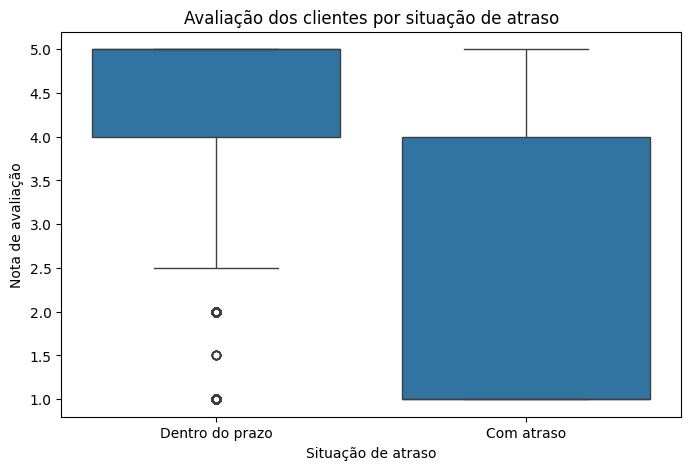

In [74]:
# Visualizando as avaliações por situação de atraso

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='atraso',
    y='review_score'
)

plt.title('Avaliação dos clientes por situação de atraso')
plt.xlabel('Situação de atraso')
plt.ylabel('Nota de avaliação')

plt.xticks(
    ticks=[0, 1],
    labels=['Dentro do prazo', 'Com atraso']
)

plt.show()

O boxplot reforça a diferença entre as avaliações dos pedidos entregues dentro do prazo e dos pedidos com atraso. Nos pedidos dentro do prazo, a distribuição das notas está concentrada em valores mais altos, principalmente entre 4 e 5, indicando maior satisfação dos clientes.

Nos pedidos com atraso, observa-se uma concentração maior de avaliações baixas, com mediana próxima de 1. Isso mostra que o atraso na entrega tem impacto direto e negativo na percepção do cliente sobre a compra.

Apesar de existirem pedidos atrasados com notas altas, a tendência geral é clara: pedidos entregues fora do prazo recebem avaliações consideravelmente menores. Dessa forma, a variável de atraso se mostra uma das mais relevantes para explicar a queda na satisfação dos clientes.

### Proporção de avaliações baixas por situação de atraso

Além de comparar as médias e a distribuição das notas, será analisada a proporção de pedidos com avaliação baixa em cada situação de atraso. Para esta análise, serão consideradas avaliações baixas as notas menores ou iguais a 2.

Essa etapa permite verificar de forma mais direta se os pedidos com atraso concentram maior percentual de clientes insatisfeitos.

In [75]:
# Criando variável para identificar avaliações baixas

df['avaliacao_baixa'] = (df['review_score'] <= 2).astype(int)

avaliacao_baixa_atraso = df.groupby('atraso').agg(
    total_pedidos=('order_id', 'count'),
    avaliacoes_baixas=('avaliacao_baixa', 'sum'),
    percentual_avaliacao_baixa=('avaliacao_baixa', 'mean')
).reset_index()

avaliacao_baixa_atraso['percentual_avaliacao_baixa'] = (
    avaliacao_baixa_atraso['percentual_avaliacao_baixa'] * 100
).round(2)

avaliacao_baixa_atraso['Situação'] = avaliacao_baixa_atraso['atraso'].map({
    0: 'Dentro do prazo',
    1: 'Com atraso'
})

avaliacao_baixa_atraso = avaliacao_baixa_atraso[
    ['Situação', 'total_pedidos', 'avaliacoes_baixas', 'percentual_avaliacao_baixa']
]

print('Proporção de avaliações baixas por situação de atraso:')
avaliacao_baixa_atraso

Proporção de avaliações baixas por situação de atraso:


,Situação,total_pedidos,avaliacoes_baixas,percentual_avaliacao_baixa
0,Dentro do prazo,89936,8257,9.18
1,Com atraso,6534,3979,60.90


A análise da proporção de avaliações baixas mostra uma diferença expressiva entre os pedidos entregues dentro do prazo e os pedidos com atraso.

Entre os pedidos entregues dentro do prazo, 9,18% receberam avaliação baixa, ou seja, nota menor ou igual a 2. Já entre os pedidos com atraso, esse percentual foi de 60,90%, indicando que mais da metade dos pedidos atrasados recebeu avaliação negativa.

Esse resultado reforça de forma objetiva que o atraso na entrega está fortemente associado à insatisfação dos clientes. Embora existam outros fatores que possam influenciar a avaliação, a diferença entre os dois grupos mostra que a pontualidade da entrega é um fator crítico para a experiência do cliente.

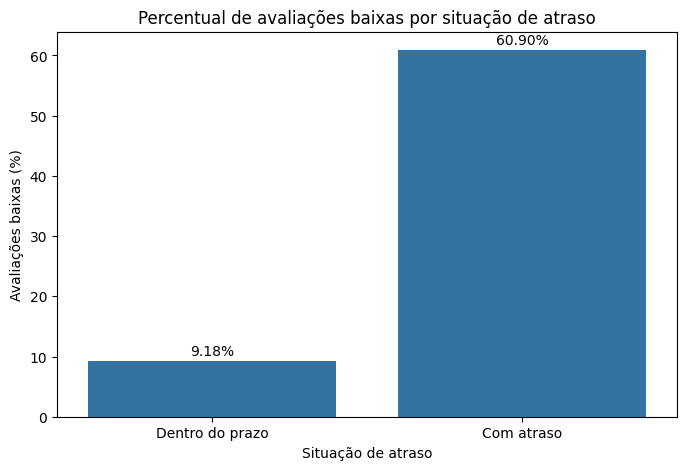

In [76]:
# Visualizando a proporção de avaliações baixas por situação de atraso

plt.figure(figsize=(8, 5))

sns.barplot(
    data=avaliacao_baixa_atraso,
    x='Situação',
    y='percentual_avaliacao_baixa'
)

plt.title('Percentual de avaliações baixas por situação de atraso')
plt.xlabel('Situação de atraso')
plt.ylabel('Avaliações baixas (%)')

for i, valor in enumerate(avaliacao_baixa_atraso['percentual_avaliacao_baixa']):
    plt.text(i, valor + 1, f'{valor:.2f}%', ha='center')

plt.show()

O gráfico evidencia a diferença na proporção de avaliações baixas entre os pedidos entregues dentro do prazo e os pedidos com atraso.

Nos pedidos dentro do prazo, apenas 9,18% das avaliações foram baixas. Já nos pedidos com atraso, esse percentual chegou a 60,90%, mostrando uma elevação expressiva na insatisfação dos clientes quando a entrega ocorre fora do prazo.

Esse resultado reforça que o atraso na entrega possui forte relação com a pior avaliação do cliente. Diferentemente de outras variáveis analisadas, como valor do produto e valor do frete, a variável de atraso apresenta uma diferença muito mais clara entre os grupos, indicando que a pontualidade da entrega é um fator crítico para a experiência do consumidor.

### Síntese da análise das avaliações dos clientes

A análise das avaliações mostrou que os pedidos com atraso recebem notas consideravelmente menores do que os pedidos entregues dentro do prazo. Enquanto os pedidos dentro do prazo apresentaram média de avaliação de 4,29 e mediana igual a 5, os pedidos com atraso apresentaram média de 2,27 e mediana igual a 1.

Além disso, a proporção de avaliações baixas foi muito superior entre os pedidos atrasados, chegando a 60,90%, contra apenas 9,18% nos pedidos entregues dentro do prazo. Esse resultado indica que o atraso não apenas reduz a nota média, mas também aumenta fortemente a ocorrência de avaliações negativas.

Dessa forma, a variável de atraso se mostra diretamente associada à satisfação do cliente, sendo uma das evidências mais relevantes da análise exploratória realizada.

## Síntese geral da análise exploratória

A análise exploratória permitiu identificar os principais fatores associados aos atrasos nas entregas da base analítica. De forma geral, a maior parte dos pedidos foi entregue dentro do prazo, porém os pedidos com atraso apresentaram comportamento bastante distinto em relação ao tempo de entrega, à avaliação dos clientes e a algumas características regionais e operacionais.

Inicialmente, observou-se que 6,77% dos pedidos foram classificados como atrasados, enquanto 93,23% foram entregues dentro do prazo. Apesar de representar uma parcela menor da base, o grupo de pedidos com atraso apresentou tempo de entrega consideravelmente mais elevado, com média de 33,49 dias e mediana de 31 dias, contra média de 10,54 dias e mediana de 9 dias para os pedidos dentro do prazo.

A análise regional mostrou que os atrasos não devem ser avaliados apenas pelo percentual, mas também pelo volume absoluto de pedidos atrasados. Estados como AL e MA apresentaram percentuais mais elevados, porém com volumes menores. Por outro lado, SP e RJ concentraram grande quantidade absoluta de atrasos, indicando maior impacto operacional. Na análise das rotas entre estado do vendedor e estado do cliente, observou-se concentração relevante de atrasos em rotas com origem em SP, especialmente em combinações como SP → SP e SP → RJ.

Na análise por categoria de produto, verificou-se que algumas categorias apresentaram maior percentual de atraso, mas muitas delas possuíam baixo volume de pedidos. Ao considerar a quantidade absoluta e a participação no total de atrasos, categorias como bed_bath_table, health_beauty, sports_leisure, furniture_decor, computers_accessories e watches_gifts se destacaram por concentrarem maior impacto operacional.

As variáveis relacionadas ao valor dos produtos e ao valor do frete apresentaram diferenças entre pedidos dentro do prazo e pedidos com atraso, porém essas diferenças não foram suficientemente fortes para explicar isoladamente o atraso. Os pedidos atrasados apresentaram valores medianos ligeiramente superiores, mas a análise indica que essas variáveis devem ser interpretadas em conjunto com fatores logísticos, regionais e de categoria.

Por fim, a análise das avaliações dos clientes mostrou uma relação expressiva entre atraso e insatisfação. Os pedidos entregues dentro do prazo apresentaram média de avaliação de 4,29 e mediana igual a 5, enquanto os pedidos com atraso apresentaram média de 2,27 e mediana igual a 1. Além disso, 60,90% dos pedidos atrasados receberam avaliações baixas, contra apenas 9,18% entre os pedidos entregues dentro do prazo.

Dessa forma, a análise exploratória indica que o atraso na entrega é um fator crítico para a experiência do cliente. Embora represente uma parcela menor dos pedidos, ele está associado a maiores tempos de entrega, pior avaliação e maior risco de insatisfação. Os resultados também mostram que a investigação dos atrasos deve considerar simultaneamente fatores regionais, rotas logísticas, categorias de produto e características operacionais dos pedidos.

# Modelagem preditiva


Após a análise exploratória dos dados, será construída uma etapa de modelagem com o objetivo de prever se um pedido possui risco de atraso na entrega.

A variável alvo será `atraso`, em que o valor 0 representa pedidos entregues dentro do prazo e o valor 1 representa pedidos entregues com atraso.

Para evitar vazamento de informação, não serão utilizadas variáveis que só são conhecidas após a entrega, como tempo real de entrega, diferença entre entrega real e estimada e avaliação do cliente. Dessa forma, o modelo será construído com variáveis relacionadas ao pedido, localização, categoria do produto, valor dos produtos e valor do frete.

Como a quantidade de pedidos atrasados é menor do que a quantidade de pedidos entregues dentro do prazo, a base apresenta desbalanceamento. Por esse motivo, além da acurácia, serão avaliadas métricas como precision, recall, f1-score e matriz de confusão.

In [78]:
# Importações complementares para a etapa de modelagem

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay

print('Importações complementares realizadas com sucesso.')

Importações complementares realizadas com sucesso.


In [80]:
# Criando uma cópia da base para modelagem
df_modelo = df.copy()
df_modelo.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega_dias,diferenca_entrega_dias,atraso,quantidade_itens,valor_produtos,valor_frete,quantidade_vendedores,customer_city,customer_state,review_score,quantidade_reviews,product_category_name,product_category_name_english,seller_id,seller_city,seller_state,avaliacao_baixa
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,0,1,29.99,8.72,1,sao paulo,SP,4.00,1.00,utilidades_domesticas,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,0,1,118.70,22.76,1,barreiras,BA,4.00,1.00,perfumaria,perfumery,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,0,1,159.90,19.22,1,vianopolis,GO,5.00,1.00,automotivo,auto,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,0,1,45.00,27.20,1,sao goncalo do amarante,RN,5.00,1.00,pet_shop,pet_shop,66922902710d126a0e7d26b0e3805106,belo horizonte,MG,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,0,1,19.90,8.72,1,santo andre,SP,5.00,1.00,papelaria,stationery,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,SP,0


## Preparação da base para modelagem

Nesta etapa, será criada uma base específica para a modelagem preditiva. O objetivo é selecionar apenas as variáveis que podem ser conhecidas antes da finalização da entrega, evitando o uso de informações que só estariam disponíveis depois que o pedido já foi concluído.

A variável alvo será `atraso`, que indica se o pedido foi entregue dentro do prazo ou com atraso.

In [83]:
# Conferindo as variáveis disponíveis para a modelagem

colunas_necessarias = [
    'customer_state',
    'seller_state',
    'product_category_name_english',
    'valor_produtos',
    'valor_frete',
    'atraso'
]

colunas_faltantes = [
    coluna for coluna in colunas_necessarias
    if coluna not in df.columns
]

print('Quantidade de linhas e colunas da base original:')
print(df.shape)

print('\nColunas faltantes para a modelagem:')
print(colunas_faltantes)

df[colunas_necessarias].head()

Quantidade de linhas e colunas da base original:
(96470, 25)

Colunas faltantes para a modelagem:
[]


,customer_state,seller_state,product_category_name_english,valor_produtos,valor_frete,atraso
0,SP,SP,housewares,29.99,8.72,0
1,BA,SP,perfumery,118.70,22.76,0
2,GO,SP,auto,159.90,19.22,0
3,RN,MG,pet_shop,45.00,27.20,0
4,SP,SP,stationery,19.90,8.72,0


Após confirmar que as variáveis necessárias estão disponíveis na base, será criada uma base específica para a modelagem preditiva.

Além das variáveis já selecionadas, será criada a variável `rota_estado`, formada pela combinação entre o estado do vendedor e o estado do cliente. Essa variável ajuda a representar a relação logística entre origem e destino do pedido.

In [85]:
# Criando base específica para modelagem

df_modelo = df.copy()

df_modelo['rota_estado'] = (
    df_modelo['seller_state'].astype(str) + ' -> ' + df_modelo['customer_state'].astype(str)
)

variaveis_modelo = [
    'customer_state',
    'seller_state',
    'rota_estado',
    'product_category_name_english',
    'valor_produtos',
    'valor_frete'
]

df_modelo = df_modelo[variaveis_modelo + ['atraso']].dropna(subset=['atraso'])

print('Quantidade de linhas e colunas da base de modelagem:')
print(df_modelo.shape)

df_modelo.head()

Quantidade de linhas e colunas da base de modelagem:
(96470, 7)


,customer_state,seller_state,rota_estado,product_category_name_english,valor_produtos,valor_frete,atraso
0,SP,SP,SP -> SP,housewares,29.99,8.72,0
1,BA,SP,SP -> BA,perfumery,118.70,22.76,0
2,GO,SP,SP -> GO,auto,159.90,19.22,0
3,RN,MG,MG -> RN,pet_shop,45.00,27.20,0
4,SP,SP,SP -> SP,stationery,19.90,8.72,0


## Distribuição da variável alvo

Antes de iniciar a modelagem, será analisada a distribuição da variável `atraso`. Essa etapa é importante para verificar o equilíbrio entre as classes, pois bases muito desbalanceadas podem influenciar o desempenho dos modelos.

A variável `atraso` possui valor 0 para pedidos entregues dentro do prazo e valor 1 para pedidos entregues com atraso.

In [86]:
# Analisando a distribuição da variável alvo

distribuicao_atraso = df_modelo['atraso'].value_counts().reset_index()
distribuicao_atraso.columns = ['atraso', 'quantidade']

distribuicao_atraso['percentual'] = (
    distribuicao_atraso['quantidade'] / distribuicao_atraso['quantidade'].sum() * 100
).round(2)

distribuicao_atraso['Situação'] = distribuicao_atraso['atraso'].map({
    0: 'Dentro do prazo',
    1: 'Com atraso'
})

distribuicao_atraso = distribuicao_atraso[['Situação', 'atraso', 'quantidade', 'percentual']]

print('Distribuição da variável alvo:')
distribuicao_atraso

Distribuição da variável alvo:


,Situação,atraso,quantidade,percentual
0,Dentro do prazo,0,89936,93.23
1,Com atraso,1,6534,6.77


A distribuição da variável `atraso` mostra que a maior parte dos pedidos foi entregue dentro do prazo, enquanto uma parcela menor apresentou atraso. Esse comportamento é esperado, pois em uma operação logística regular a quantidade de entregas dentro do prazo tende a ser maior do que a quantidade de atrasos.

No entanto, como o objetivo da modelagem é identificar pedidos com risco de atraso, essa diferença entre as classes precisa ser considerada. Um modelo pode apresentar alta acurácia apenas por prever a maioria dos pedidos como entregues dentro do prazo, sem necessariamente conseguir identificar bem os casos de atraso.

Por esse motivo, a avaliação dos modelos não será baseada apenas na acurácia. Também serão analisadas métricas como precisão, recall, F1-score, matriz de confusão e ROC AUC, com atenção especial ao desempenho na classe de atraso.

## Separação entre variáveis explicativas e variável alvo

Nesta etapa, a base será separada entre variáveis explicativas e variável alvo. As variáveis explicativas serão utilizadas para prever a ocorrência de atraso, enquanto a variável `atraso` será usada como resposta do modelo.

Também será feita a separação entre base de treino e base de teste, mantendo a proporção original das classes por meio do parâmetro `stratify`.

In [89]:
# Separando variáveis explicativas e variável alvo

X = df_modelo[variaveis_modelo]
y = df_modelo['atraso']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('Tamanho da base de treino:')
print(X_train.shape)

print('\nTamanho da base de teste:')
print(X_test.shape)

print('\nDistribuição da variável alvo na base de treino:')
print(y_train.value_counts(normalize=True).round(4))

print('\nDistribuição da variável alvo na base de teste:')
print(y_test.value_counts(normalize=True).round(4))

X_train.head()

Tamanho da base de treino:
(67529, 6)

Tamanho da base de teste:
(28941, 6)

Distribuição da variável alvo na base de treino:
atraso
0   0.93
1   0.07
Name: proportion, dtype: float64

Distribuição da variável alvo na base de teste:
atraso
0   0.93
1   0.07
Name: proportion, dtype: float64


,customer_state,seller_state,rota_estado,product_category_name_english,valor_produtos,valor_frete
29205,SP,RJ,RJ -> SP,sports_leisure,21.60,15.10
36300,MG,SP,SP -> MG,baby,169.90,29.37
68753,SP,PR,PR -> SP,musical_instruments,599.00,24.68
42823,SP,SP,SP -> SP,watches_gifts,29.00,7.46
36423,PR,SP,SP -> PR,office_furniture,229.99,62.35


A separação entre treino e teste manteve a proporção original da variável alvo. Tanto na base de treino quanto na base de teste, aproximadamente 93% dos pedidos pertencem à classe dentro do prazo e 7% à classe com atraso.

Essa divisão é adequada para a modelagem, pois permite avaliar os modelos em uma base de teste com distribuição semelhante à base original, evitando distorções na comparação dos resultados.

## Pré-processamento das variáveis

Como a base possui variáveis categóricas e numéricas, será criado um pré-processamento específico para cada tipo de variável.

As variáveis categóricas serão transformadas por meio de OneHotEncoder, permitindo que os modelos utilizem informações como estado do cliente, estado do vendedor, rota e categoria do produto. Já as variáveis numéricas serão padronizadas com StandardScaler, especialmente para beneficiar modelos sensíveis à escala dos dados.

In [91]:
# Definindo variáveis categóricas e numéricas

variaveis_categoricas = [
    'customer_state',
    'seller_state',
    'rota_estado',
    'product_category_name_english'
]

variaveis_numericas = [
    'valor_produtos',
    'valor_frete'
]

pre_processamento = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), variaveis_categoricas),
        ('num', StandardScaler(), variaveis_numericas)
    ]
)

print('Variáveis categóricas utilizadas:')
print(variaveis_categoricas)

print('\nVariáveis numéricas utilizadas:')
print(variaveis_numericas)

Variáveis categóricas utilizadas:
['customer_state', 'seller_state', 'rota_estado', 'product_category_name_english']

Variáveis numéricas utilizadas:
['valor_produtos', 'valor_frete']


## Modelo base com Regressão Logística

O primeiro modelo utilizado será a Regressão Logística. Esse modelo será usado como referência inicial para avaliar a capacidade de previsão da variável `atraso`.

Como a base possui desbalanceamento entre pedidos dentro do prazo e pedidos com atraso, será utilizado o parâmetro `class_weight='balanced'`, para dar maior peso à classe minoritária durante o treinamento.

In [92]:
# Criando modelo base com Regressão Logística

modelo_logistico = Pipeline(steps=[
    ('pre_processamento', pre_processamento),
    ('modelo', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

modelo_logistico.fit(X_train, y_train)

y_pred_logistico = modelo_logistico.predict(X_test)
y_proba_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

print('Modelo de Regressão Logística treinado com sucesso.')

Modelo de Regressão Logística treinado com sucesso.


In [93]:
# Avaliando o modelo de Regressão Logística

accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
precision_logistico = precision_score(y_test, y_pred_logistico)
recall_logistico = recall_score(y_test, y_pred_logistico)
f1_logistico = f1_score(y_test, y_pred_logistico)
roc_auc_logistico = roc_auc_score(y_test, y_proba_logistico)

print('Métricas do modelo de Regressão Logística:')
print('Acurácia:', round(accuracy_logistico, 4))
print('Precisão:', round(precision_logistico, 4))
print('Recall:', round(recall_logistico, 4))
print('F1-score:', round(f1_logistico, 4))
print('ROC AUC:', round(roc_auc_logistico, 4))

print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred_logistico))

Métricas do modelo de Regressão Logística:
Acurácia: 0.6787
Precisão: 0.1141
Recall: 0.5536
F1-score: 0.1892
ROC AUC: 0.6479

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     26981
           1       0.11      0.55      0.19      1960

    accuracy                           0.68     28941
   macro avg       0.53      0.62      0.49     28941
weighted avg       0.90      0.68      0.76     28941



A Regressão Logística apresentou desempenho inicial razoável para um modelo base, mas com limitações importantes. A acurácia ficou elevada, porém essa métrica deve ser interpretada com cautela devido ao desbalanceamento da variável alvo.

Ao observar a classe de atraso, percebe-se que o modelo conseguiu identificar parte dos pedidos atrasados, refletido pelo recall. No entanto, a precisão da classe com atraso foi baixa, indicando que muitos pedidos classificados como atrasados pelo modelo não estavam realmente atrasados.

Esse comportamento é esperado em bases desbalanceadas, especialmente com o uso do parâmetro `class_weight='balanced'`, que aumenta a sensibilidade do modelo à classe minoritária. Assim, a Regressão Logística será mantida como modelo de referência, mas será comparada com outros algoritmos para verificar se é possível melhorar o equilíbrio entre precisão, recall e F1-score.

## Modelo com Árvore de Decisão

O segundo modelo utilizado será a Árvore de Decisão. Esse modelo permite capturar relações não lineares entre as variáveis explicativas e a variável alvo, podendo identificar padrões mais específicos associados aos atrasos.

Assim como na Regressão Logística, será utilizado o parâmetro `class_weight='balanced'` para considerar o desbalanceamento entre pedidos dentro do prazo e pedidos com atraso.

In [94]:
# Criando modelo com Árvore de Decisão

modelo_arvore = Pipeline(steps=[
    ('pre_processamento', pre_processamento),
    ('modelo', DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42
    ))
])

modelo_arvore.fit(X_train, y_train)

y_pred_arvore = modelo_arvore.predict(X_test)
y_proba_arvore = modelo_arvore.predict_proba(X_test)[:, 1]

print('Modelo de Árvore de Decisão treinado com sucesso.')

Modelo de Árvore de Decisão treinado com sucesso.


In [95]:
# Avaliando o modelo de Árvore de Decisão

accuracy_arvore = accuracy_score(y_test, y_pred_arvore)
precision_arvore = precision_score(y_test, y_pred_arvore)
recall_arvore = recall_score(y_test, y_pred_arvore)
f1_arvore = f1_score(y_test, y_pred_arvore)
roc_auc_arvore = roc_auc_score(y_test, y_proba_arvore)

print('Métricas do modelo de Árvore de Decisão:')
print('Acurácia:', round(accuracy_arvore, 4))
print('Precisão:', round(precision_arvore, 4))
print('Recall:', round(recall_arvore, 4))
print('F1-score:', round(f1_arvore, 4))
print('ROC AUC:', round(roc_auc_arvore, 4))

print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred_arvore))

Métricas do modelo de Árvore de Decisão:
Acurácia: 0.6282
Precisão: 0.1044
Recall: 0.5923
F1-score: 0.1775
ROC AUC: 0.6373

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      0.63      0.76     26981
           1       0.10      0.59      0.18      1960

    accuracy                           0.63     28941
   macro avg       0.53      0.61      0.47     28941
weighted avg       0.90      0.63      0.72     28941



A Árvore de Decisão apresentou comportamento semelhante ao modelo de Regressão Logística, com maior sensibilidade para identificar pedidos com atraso, mas ainda com baixa precisão para a classe minoritária.

O recall da classe com atraso foi elevado, indicando que o modelo conseguiu capturar uma parcela relevante dos pedidos atrasados. No entanto, a precisão permaneceu baixa, mostrando que muitos pedidos previstos como atraso não eram realmente atrasados.

Esse resultado indica que a Árvore de Decisão consegue identificar padrões associados ao atraso, mas ainda gera muitos falsos positivos. Por isso, será necessário comparar esse desempenho com outros modelos, buscando um melhor equilíbrio entre precisão, recall, F1-score e ROC AUC.

## Modelo com Random Forest

O terceiro modelo utilizado será o Random Forest. Esse algoritmo combina várias árvores de decisão, reduzindo a dependência de uma única árvore e buscando melhorar a capacidade de generalização do modelo.

Como a variável alvo apresenta desbalanceamento entre pedidos dentro do prazo e pedidos com atraso, também será utilizado o parâmetro `class_weight='balanced'`.

In [96]:
# Criando modelo com Random Forest

modelo_random_forest = Pipeline(steps=[
    ('pre_processamento', pre_processamento),
    ('modelo', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

modelo_random_forest.fit(X_train, y_train)

y_pred_random_forest = modelo_random_forest.predict(X_test)
y_proba_random_forest = modelo_random_forest.predict_proba(X_test)[:, 1]

print('Modelo Random Forest treinado com sucesso.')

Modelo Random Forest treinado com sucesso.


In [97]:
# Avaliando o modelo Random Forest

accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)
precision_random_forest = precision_score(y_test, y_pred_random_forest)
recall_random_forest = recall_score(y_test, y_pred_random_forest)
f1_random_forest = f1_score(y_test, y_pred_random_forest)
roc_auc_random_forest = roc_auc_score(y_test, y_proba_random_forest)

print('Métricas do modelo Random Forest:')
print('Acurácia:', round(accuracy_random_forest, 4))
print('Precisão:', round(precision_random_forest, 4))
print('Recall:', round(recall_random_forest, 4))
print('F1-score:', round(f1_random_forest, 4))
print('ROC AUC:', round(roc_auc_random_forest, 4))

print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred_random_forest))

Métricas do modelo Random Forest:
Acurácia: 0.6665
Precisão: 0.112
Recall: 0.5663
F1-score: 0.187
ROC AUC: 0.647

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     26981
           1       0.11      0.57      0.19      1960

    accuracy                           0.67     28941
   macro avg       0.53      0.62      0.49     28941
weighted avg       0.90      0.67      0.75     28941



O modelo Random Forest apresentou desempenho semelhante aos modelos anteriores. Apesar de combinar várias árvores de decisão e ter maior capacidade de generalização, o modelo ainda encontrou dificuldade para prever corretamente a classe de atraso.

A acurácia ficou em torno de 67%, mas essa métrica deve ser analisada com cautela, pois a base possui forte desbalanceamento entre pedidos dentro do prazo e pedidos com atraso. Para a classe com atraso, o modelo apresentou recall razoável, indicando que conseguiu identificar parte dos pedidos atrasados. No entanto, a precisão permaneceu baixa, mostrando que muitos pedidos previstos como atraso não eram realmente atrasados.

Esse resultado indica que, mesmo com um modelo mais robusto, as variáveis disponíveis antes da finalização da entrega não são suficientes para separar perfeitamente os pedidos atrasados dos pedidos dentro do prazo. Ainda assim, o Random Forest será considerado na comparação final, principalmente pelas métricas de recall, F1-score e ROC AUC.

## Comparação dos modelos

Após treinar os modelos de Regressão Logística, Árvore de Decisão e Random Forest, será criada uma tabela consolidada com as principais métricas de avaliação.

Como a variável alvo é desbalanceada, a comparação não deve considerar apenas a acurácia. As métricas de precisão, recall, F1-score e ROC AUC são importantes para avaliar o desempenho dos modelos na identificação dos pedidos com atraso.

In [98]:
# Comparando os modelos treinados

comparacao_modelos = pd.DataFrame({
    'Modelo': [
        'Regressão Logística',
        'Árvore de Decisão',
        'Random Forest'
    ],
    'Acurácia': [
        accuracy_logistico,
        accuracy_arvore,
        accuracy_random_forest
    ],
    'Precisão': [
        precision_logistico,
        precision_arvore,
        precision_random_forest
    ],
    'Recall': [
        recall_logistico,
        recall_arvore,
        recall_random_forest
    ],
    'F1-score': [
        f1_logistico,
        f1_arvore,
        f1_random_forest
    ],
    'ROC AUC': [
        roc_auc_logistico,
        roc_auc_arvore,
        roc_auc_random_forest
    ]
})

comparacao_modelos = comparacao_modelos.round(4)

print('Comparação dos modelos:')
comparacao_modelos

Comparação dos modelos:


,Modelo,Acurácia,Precisão,Recall,F1-score,ROC AUC
0,Regressão Logística,0.68,0.11,0.55,0.19,0.65
1,Árvore de Decisão,0.63,0.10,0.59,0.18,0.64
2,Random Forest,0.67,0.11,0.57,0.19,0.65


A comparação dos modelos mostra que os desempenhos foram bastante próximos. A Regressão Logística e o Random Forest apresentaram os melhores resultados gerais, com F1-score de 0,19 e ROC AUC de 0,65. A Árvore de Decisão apresentou recall ligeiramente maior para a classe de atraso, mas teve menor acurácia e F1-score.

Como a variável alvo é desbalanceada, a acurácia não deve ser analisada isoladamente. O foco principal está na capacidade de identificar pedidos com atraso, representada principalmente pelo recall, F1-score e ROC AUC.

De forma geral, nenhum dos modelos conseguiu separar perfeitamente os pedidos atrasados dos pedidos entregues dentro do prazo. Isso indica que, com as variáveis disponíveis antes da finalização da entrega, existe uma limitação natural na previsão do atraso. Ainda assim, os modelos conseguem capturar parte dos pedidos com maior risco de atraso, podendo ser úteis como apoio à priorização logística.

Entre os modelos avaliados, a Regressão Logística e o Random Forest apresentaram desempenho muito semelhante. A Regressão Logística se destaca pela simplicidade e interpretabilidade, enquanto o Random Forest possui maior capacidade de capturar relações não lineares. Para este projeto, a Regressão Logística pode ser considerada o modelo base de referência, enquanto o Random Forest representa uma alternativa mais robusta para comparação.

## Matriz de confusão do modelo escolhido

Para complementar a avaliação do modelo, será analisada a matriz de confusão da Regressão Logística. Essa matriz permite observar a quantidade de acertos e erros para cada classe, mostrando quantos pedidos dentro do prazo e com atraso foram classificados corretamente ou incorretamente.

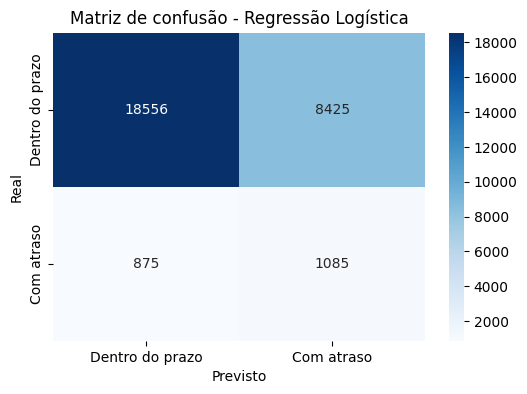

In [99]:
# Matriz de confusão da Regressão Logística

matriz_logistica = confusion_matrix(y_test, y_pred_logistico)

plt.figure(figsize=(6, 4))

sns.heatmap(
    matriz_logistica,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Dentro do prazo', 'Com atraso'],
    yticklabels=['Dentro do prazo', 'Com atraso']
)

plt.title('Matriz de confusão - Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

A matriz de confusão da Regressão Logística mostra que o modelo conseguiu classificar corretamente 18.556 pedidos dentro do prazo e 1.085 pedidos com atraso.

No entanto, também houve quantidade relevante de falsos positivos, com 8.425 pedidos dentro do prazo classificados incorretamente como atraso. Além disso, 875 pedidos realmente atrasados foram classificados como dentro do prazo.

Esse resultado confirma o comportamento observado nas métricas anteriores: o modelo possui capacidade de identificar parte dos atrasos, mas ainda apresenta dificuldade para separar com precisão os pedidos atrasados dos pedidos entregues dentro do prazo. Na prática, isso significa que o modelo pode ser útil para sinalizar pedidos com maior risco de atraso, mas não deve ser utilizado como decisão definitiva sem análise complementar.

## Curva ROC do modelo escolhido

A curva ROC será utilizada para avaliar a capacidade do modelo em distinguir pedidos dentro do prazo e pedidos com atraso em diferentes pontos de corte.

Essa análise complementa as métricas anteriores, pois considera as probabilidades estimadas pelo modelo, e não apenas a classificação final.

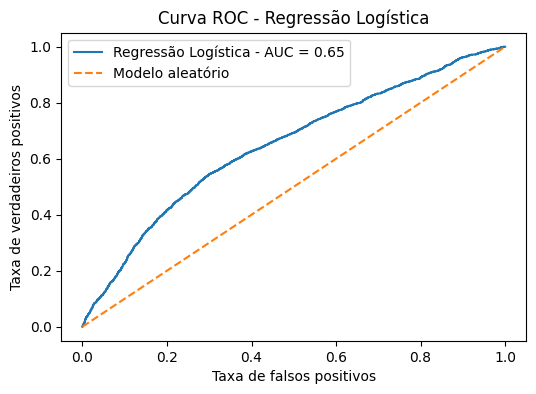

In [102]:
# Curva ROC da Regressão Logística

fpr_logistico, tpr_logistico, thresholds_logistico = roc_curve(y_test, y_proba_logistico)

plt.figure(figsize=(6, 4))

plt.plot(fpr_logistico, tpr_logistico, label=f'Regressão Logística - AUC = {roc_auc_logistico:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo aleatório')

plt.title('Curva ROC - Regressão Logística')
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.legend()

plt.show()

A curva ROC da Regressão Logística apresentou AUC de 0,65. Esse resultado indica que o modelo possui capacidade moderada de distinguir pedidos dentro do prazo e pedidos com atraso.

A curva ficou acima da linha do modelo aleatório, mostrando que o modelo consegue capturar algum padrão nos dados. No entanto, o valor de AUC ainda não é alto, o que reforça que a previsão de atraso possui limitações com as variáveis disponíveis antes da finalização da entrega.

Assim, o modelo pode ser utilizado como apoio para identificar pedidos com maior risco de atraso, mas não deve ser interpretado como uma ferramenta de decisão definitiva. Para melhorar o desempenho, seria importante incluir novas variáveis logísticas, como distância real, transportadora, tipo de envio, prazo prometido e histórico operacional.

## Salvamento do modelo escolhido

Após a comparação dos modelos, a Regressão Logística foi escolhida como modelo de referência por apresentar desempenho semelhante ao Random Forest, mas com maior simplicidade e interpretabilidade.

Nesta etapa, o modelo será salvo em arquivo `.pkl`, permitindo sua reutilização posterior sem necessidade de novo treinamento.

In [103]:
# Salvando o modelo escolhido

import joblib

joblib.dump(modelo_logistico, '../output/modelo_regressao_logistica.pkl')

print('Modelo salvo com sucesso em ../output/modelo_regressao_logistica.pkl')

Modelo salvo com sucesso em ../output/modelo_regressao_logistica.pkl


## Conclusão final

O projeto teve como objetivo analisar os fatores associados aos atrasos nas entregas da base Olist e construir modelos preditivos capazes de identificar pedidos com maior risco de atraso.

Na etapa exploratória, observou-se que a maior parte dos pedidos foi entregue dentro do prazo. Os pedidos classificados como atraso representaram uma parcela menor da base, cerca de 6,77% do total analisado, enquanto aproximadamente 93,23% foram entregues dentro do prazo. Dessa forma, o atraso não aparece como um problema predominante em volume geral de pedidos.

Apesar de representar uma parcela menor da base, o atraso apresentou relação importante com a experiência do cliente. Os pedidos entregues dentro do prazo tiveram avaliações médias mais altas, enquanto os pedidos com atraso apresentaram queda expressiva nas notas. A média de avaliação dos pedidos dentro do prazo foi de aproximadamente 4,29, com mediana igual a 5, enquanto os pedidos com atraso apresentaram média de aproximadamente 2,27 e mediana igual a 1. Além disso, a proporção de avaliações baixas foi muito maior entre os pedidos atrasados.

Esses resultados indicam que o atraso não deve ser interpretado como o principal fator de impacto sobre o volume geral de pedidos, pois a maioria das entregas ocorreu dentro do prazo. No entanto, quando o atraso acontece, ele está fortemente associado à pior percepção do cliente, podendo afetar satisfação, reputação da loja, confiança no serviço e possibilidade de recompra.

A análise regional mostrou que os atrasos não devem ser avaliados apenas pelo percentual, mas também pelo volume absoluto de pedidos afetados. Alguns estados e rotas apresentaram percentuais mais elevados de atraso, mas com baixo volume de pedidos, enquanto outros concentraram maior quantidade absoluta de atrasos e, por isso, possuem maior relevância operacional. Esse resultado reforça a importância de analisar simultaneamente proporção e volume para evitar conclusões distorcidas.

Na análise por categoria de produto, verificou-se que algumas categorias apresentaram maior percentual de atraso, mas muitas delas tinham baixo volume de pedidos. Ao considerar a quantidade absoluta e a participação no total de atrasos, categorias como bed_bath_table, health_beauty, sports_leisure, furniture_decor, computers_accessories e watches_gifts se destacaram por concentrarem maior impacto operacional.

As variáveis relacionadas ao valor dos produtos e ao valor do frete apresentaram diferenças entre pedidos dentro do prazo e pedidos com atraso, mas essas diferenças não foram fortes o suficiente para explicar isoladamente o atraso. Os pedidos atrasados apresentaram valores medianos ligeiramente superiores, porém a análise indicou que essas variáveis devem ser interpretadas em conjunto com fatores regionais, rotas logísticas, categorias de produto e características operacionais.

Na etapa de modelagem, foram avaliados três modelos: Regressão Logística, Árvore de Decisão e Random Forest. Como a variável alvo é desbalanceada, a análise não foi baseada apenas na acurácia, mas também em precisão, recall, F1-score, ROC AUC, matriz de confusão e curva ROC.

Os modelos apresentaram desempenhos próximos, com destaque para a Regressão Logística e o Random Forest. A Regressão Logística foi escolhida como modelo de referência por apresentar desempenho semelhante ao Random Forest, mas com maior simplicidade e interpretabilidade.

De forma geral, os modelos conseguiram capturar parte dos pedidos com maior risco de atraso, mas ainda apresentaram limitações, principalmente pela baixa precisão na classe de atraso. Isso significa que os modelos conseguem identificar alguns padrões associados ao atraso, mas também geram falsos positivos, classificando como atraso pedidos que foram entregues dentro do prazo.

Assim, o modelo desenvolvido não deve ser utilizado como uma ferramenta de decisão definitiva, mas pode servir como apoio à priorização logística. Ele pode ajudar a sinalizar pedidos com maior risco de atraso para análise complementar, permitindo que a operação acompanhe com mais atenção determinados pedidos, rotas, categorias ou regiões.

Conclui-se que o atraso não representa a maior parte dos pedidos analisados e, portanto, não deve ser tratado como um problema generalizado da operação. Porém, quando ocorre, ele tem impacto relevante na satisfação do cliente. Por isso, a investigação dos atrasos continua sendo importante, especialmente para reduzir avaliações negativas e melhorar a experiência de compra.

Para melhorias futuras, recomenda-se incluir novas variáveis logísticas e operacionais, como distância real entre vendedor e cliente, transportadora, modalidade de envio, prazo prometido, histórico do vendedor, histórico da rota, região de origem e destino, além de indicadores relacionados ao tempo de separação, postagem e transporte. Essas informações podem aumentar a capacidade preditiva dos modelos e permitir uma análise mais precisa das causas dos atrasos.